In [1]:
%matplotlib widget

In [2]:
from astropy.io import fits
import matplotlib.pyplot as plt
import numpy as np
from scipy.optimize import curve_fit
from astropy.modeling import models
from scipy.signal import convolve
from scipy.optimize import minimize
from astropy.convolution import Gaussian1DKernel
import scipy.integrate as integrate
from scipy.optimize import differential_evolution
import pandas as pd

In [3]:
hdul = fits.open("C:/Users/ISAFA/Desktop/Tesi magistrale/Sources/UGC5823/UGC5823_1/UGC-5823_1_MAPPED_FLUX_SCI_LSS_U1.fits")
hdul.info()
image = hdul[0].data
image_error = hdul[1].data

Filename: C:/Users/ISAFA/Desktop/Tesi magistrale/Sources/UGC5823/UGC5823_1/UGC-5823_1_MAPPED_FLUX_SCI_LSS_U1.fits
No.    Name      Ver    Type      Cards   Dimensions   Format
  0  PRIMARY       1 PrimaryHDU     377   (2094, 964)   float32   
  1  IMAGE.ERR     1 ImageHDU        58   (2094, 964)   float32   


In [4]:
image_cut = image[48:168, 0:1890]
image_error_cut = image_error[48:168, 0:1890]

Text(0.5, 0, 'wavelength')

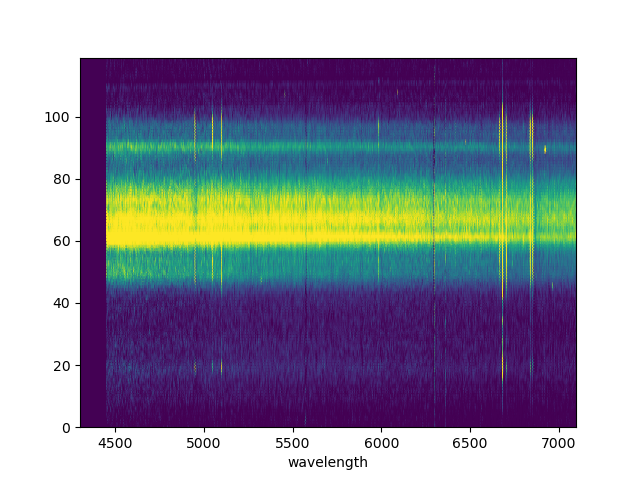

In [5]:
wavelengths = np.arange(4300.74, 4300.74+1890*1.48, 1.48)
J, N = image_cut.data.shape
#x = np.arange(0, N, 1)
y = np.arange(0, J, 1)
arcsec_y = np.arange(-58*0.256, 52*0.256, 0.256)

x_grid, y_grid = np.meshgrid(wavelengths, y)
plt.pcolormesh(x_grid, y_grid, image_cut, shading='gouraud', vmin = np.percentile(image_cut, 20), vmax=np.percentile(image_cut, 95))
plt.xlabel('wavelength')

In [6]:
z = 0.0188
l_HA = 6563 * (1+z)
l_HB = 4861 * (1+z) 
l_NII = 6583 * (1+z)
l_SII = 6717 * (1+z)
l_OIII = 5007 * (1+z)
seeing = np.loadtxt("C:/Users/ISAFA/Desktop/Tesi magistrale/Sources/UGC5823/UGC5823_1/PSF/Real_seeing_UGC5823_1.txt")
sigma = seeing[0]/2.35

In [7]:
l_HB

4952.386799999999

Text(0.5, 1.0, 'H$\\alpha$')

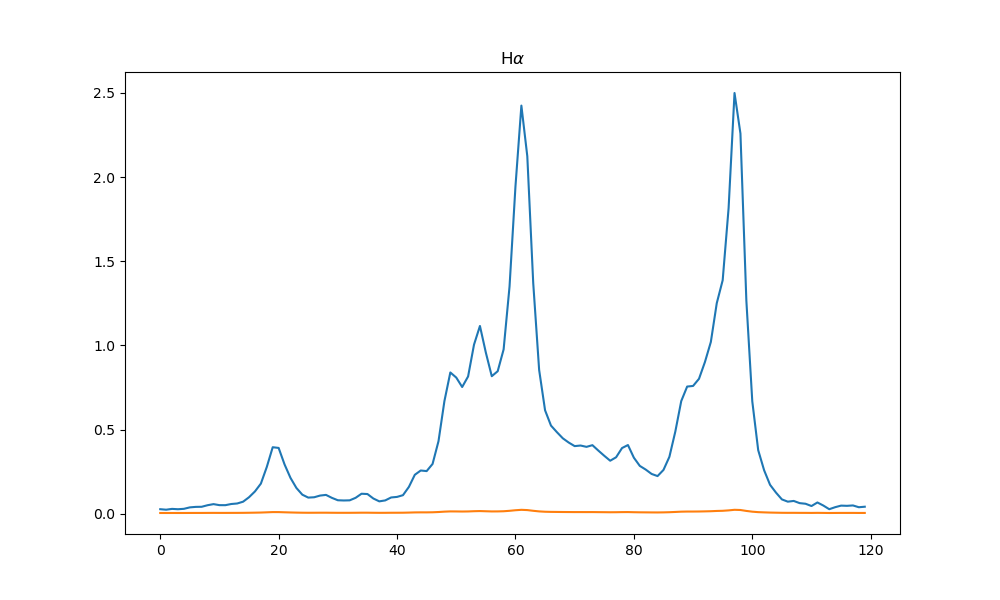

In [8]:
#Ogni punto del flusso è il risultato della somma di 20 lunghezze d'onda 
mask_HA = (wavelengths > l_HA-8)*(wavelengths < l_HA+8)
image_HA = image_cut[:, mask_HA]
image_error_HA = image_error_cut[:, mask_HA]
radial_profile_HA = np.sum(image_HA, axis = 1)
radial_profile_error_HA = np.sqrt(np.sum(image_error_HA**2, axis = 1))

x_axes = np.arange(0, 120, 1)
plt.figure(figsize=(10, 6))
plt.plot(x_axes, radial_profile_HA)
plt.plot(x_axes, radial_profile_error_HA)
plt.title(r'H$\alpha$')

In [9]:
def calculate_bn(n):
    """ Calcola b_n per il profilo Sérsic """
    return 2*n - 1/3 + 4/(405*n) + 46/(25515*n**2)

def sersic_1d(x, I_e, r_e, n, x_0):
    """ Profilo Sérsic 1D centrato in x_0 """
    r = np.abs(x - x_0)
    b_n = calculate_bn(n)
    return I_e * np.exp(-b_n * ((r / r_e)**(1 / n) - 1))

#Define the function for the aic
#Per l'AIC test usiamo il chi quadro perchè il numero di conteggi è elevato (S/N grande) 
#quindi Poisson --> Gauss
#def chi_quad(x, y, y_err, params):
#    return np.sum((((y - model_convolved(x, *params)) / y_err)**2))
    
def AIC(x, y, chi, params): #k=number of model parameter, N=number of data points
    return chi + 2*len(params) +((2*len(params)*(len(params)+1))/(len(y)-len(params)-1))

def BIC(x, y, chi, params):
        return chi + len(params)*np.log(len(y))
    
def sersic_1d_convolved(x, I_e, r_e, n, x_0):
    """ Sérsic convoluto con PSF gaussiana """
    x_hr = np.linspace(min(x), max(x), 4000)
    profile = sersic_1d(x_hr, I_e, r_e, n, x_0)
    psf = Gaussian1DKernel(stddev=(sigma*len(x_hr))/len(x), x_size=len(x_hr), mode='center')
    conv_profile = convolve(profile, psf, mode='same')
    conv_profile_out = np.interp(x, x_hr, conv_profile)
    return conv_profile_out

def save_params(params_curve, covariance, radial_profile, radial_profile_error, x_axes, n_component, line_name="", output_prefix="fit"):
    I_e = np.zeros(n_component)
    r_e = np.zeros(n_component)
    n = np.zeros(n_component)
    x_0 = np.zeros(n_component)

    I_e_err = np.zeros(n_component)
    r_e_err = np.zeros(n_component)
    n_err = np.zeros(n_component)
    x_0_err = np.zeros(n_component)

    for i in range(n_component):
        I_e[i], r_e[i], n[i], x_0[i] = params_curve[i*4:(i+1)*4]
        I_e_err[i] = np.sqrt(np.diag(covariance)[i*4])
        r_e_err[i] = np.sqrt(np.diag(covariance)[(i*4)+1])
        n_err[i] = np.sqrt(np.diag(covariance)[(i*4)+2])
        x_0_err[i] = np.sqrt(np.diag(covariance)[(i*4)+3])
        print(f"Sérsic {i+1}: I_e={I_e[i]:.4f}, r_e={r_e[i]:.4f}, n={n[i]:.4f}, x_0={x_0[i]:.4f}")

    print(np.sqrt(np.diag(covariance)))
    chi2 = np.sum((((radial_profile - model_convolved(x_axes, *params_curve)) / radial_profile_error)**2))
    dof = len(radial_profile) - len(params_curve)
    chi2_reduced = chi2 / dof
    print(chi2_reduced)

    param_dict = {}
    error_dict = {}
    
    for i in range(n_component):
        component_name = f'Component {i+1}'
        param_dict[component_name] = [I_e[i], r_e[i], n[i], x_0[i]]
        error_dict[component_name] = [I_e_err[i], r_e_err[i], n_err[i], x_0_err[i]]
    
    # Crea DataFrame
    df_params = pd.DataFrame(data=param_dict, index=['I_e', 'r_e', 'n', 'x_0'])
    df_errors = pd.DataFrame(data=error_dict, index=['I_e error', 'r_e error', 'n error', 'x_0 error'])
    
    # Salva file CSV
    if line_name:
        param_filename = f"{line_name}_{output_prefix}.csv"
        error_filename = f"{line_name}_{output_prefix}_errors.csv"
    
    df_params.to_csv(param_filename, float_format='%.4f')
    df_errors.to_csv(error_filename, float_format='%.4f')
    return chi2_reduced, chi2

In [10]:
def model_convolved(x, *params):
    x_hr = np.linspace(min(x), max(x), 4000)
    profile = (
        sersic_1d(x_hr, *params) 
        )
    kernel = Gaussian1DKernel(stddev=(sigma*len(x_hr))/len(x), x_size=len(x_hr), mode='center')   
    conv_profile = convolve(profile, kernel, mode='same')
    conv_profile_out = np.interp(x, x_hr, conv_profile)
    return conv_profile_out

def chi_squared(params, x, y_obs): #per diff evolution
    y_model = model_convolved(x, *params)
    return np.sum((y_obs - y_model)**2)

# Bounds:
bounds = [
    (0, 10),    # I_e: da 0 a 10 (o un valore ragionevole)
    (0, 50),  # r_e: da 0.1 a 50
    (0.1, 10),  # n: da 0.1 a 10
    (58, 63),  # x_0: posizione da 0 a 100
]
# objective function for differential_evolution
def objective(params):
    return chi_squared(params, x_axes, radial_profile_HA)

# Global fit:
result = differential_evolution(
    objective,
    bounds,
    strategy='best1bin',
    maxiter=1000,
    popsize=20,
    tol=1e-6,
    disp=True,
    polish=True
)

best_params1 = result.x

print("Optimize parameters with differential_evolution:", best_params1)

print("Chi quadro minimo:", result.fun)

differential_evolution step 1: f(x)= 41.1025354889009
differential_evolution step 2: f(x)= 41.1025354889009
differential_evolution step 3: f(x)= 31.656090192842044
differential_evolution step 4: f(x)= 28.961559718705963
differential_evolution step 5: f(x)= 25.762936136921965
differential_evolution step 6: f(x)= 25.762936136921965
differential_evolution step 7: f(x)= 24.54168228456171
differential_evolution step 8: f(x)= 23.595982901574338
differential_evolution step 9: f(x)= 23.595982901574338
differential_evolution step 10: f(x)= 23.48066910717385
differential_evolution step 11: f(x)= 22.99518739498618
differential_evolution step 12: f(x)= 22.99518739498618
differential_evolution step 13: f(x)= 22.99518739498618
differential_evolution step 14: f(x)= 22.834616359953262
differential_evolution step 15: f(x)= 22.550494028039285
differential_evolution step 16: f(x)= 22.550494028039285
differential_evolution step 17: f(x)= 22.550494028039285
differential_evolution step 18: f(x)= 22.50897149

Optimize parameters with curve fit:
Sérsic 1: I_e=0.0191, r_e=127.4124, n=2.9461, x_0=60.7647
[4.03868018e-02 1.95007289e+02 1.76719317e+00 2.81649392e-03]
606.3329791900906
614.680805277047 0.0 625.4829461612187 4


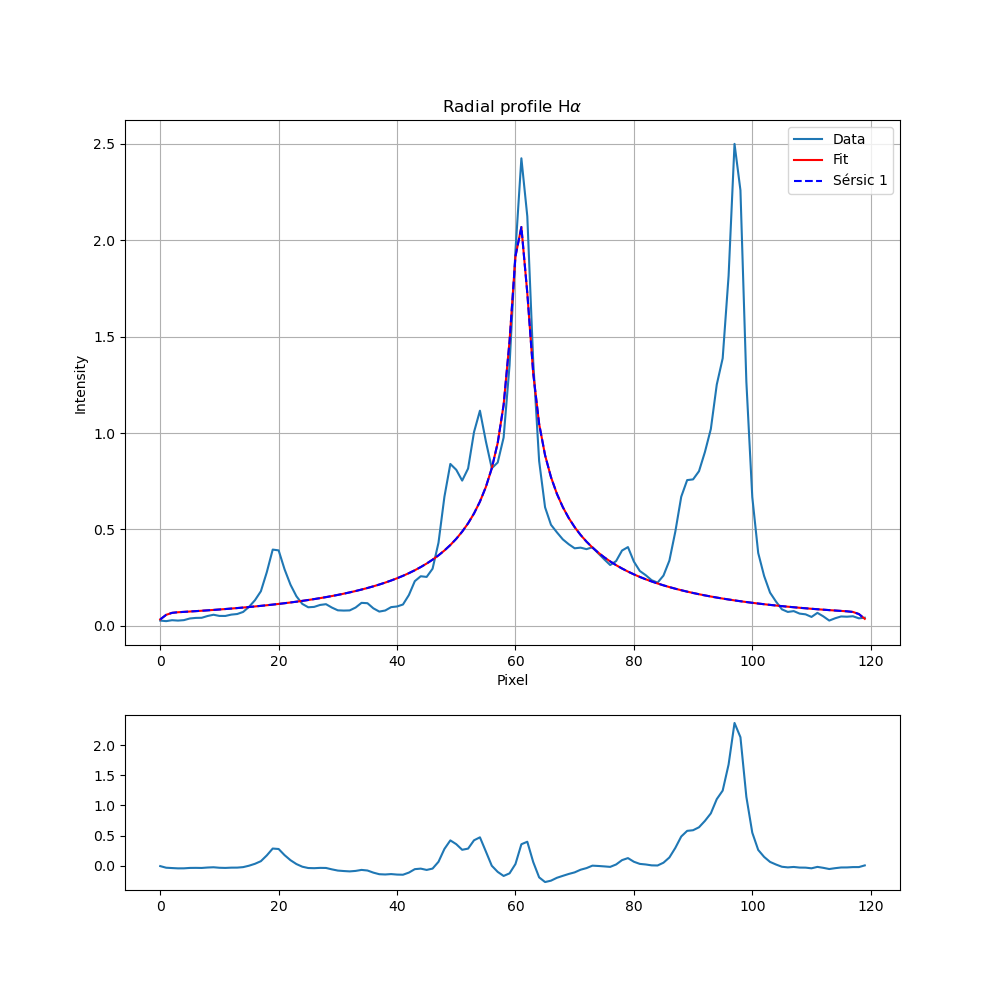

In [11]:
# Plots:
aic = np.zeros(9)
bic = np.zeros(9)
chi_quadr = np.zeros(9)
chi_quadro = np.zeros(9)
red_chi = np.zeros(9)

params_curve_1, covariance_1 = curve_fit(lambda x, *params: model_convolved(x, *params), x_axes, radial_profile_HA, p0=best_params1,
                                         sigma = radial_profile_error_HA)

print("Optimize parameters with curve fit:")

chi_quadr[0], red_chi[0] = save_params(params_curve_1, covariance_1, radial_profile_HA, radial_profile_error_HA, x_axes, 1, line_name="One", 
                                           output_prefix="fit")

aic[0] = AIC(x_axes, radial_profile_HA, chi_quadr[0], params_curve_1)
bic[0] = BIC(x_axes, radial_profile_HA, chi_quadr[0], params_curve_1)
print(aic[0], chi_quadro[0], bic[0], len(params_curve_1))

# Plots:
xgrid = np.linspace(min(x_axes), max(x_axes), 120)
y_fit = model_convolved(xgrid, *params_curve_1)

fig, ax = plt.subplots(2, 1, figsize=(10, 10), height_ratios=[3, 1])

ax[0].plot(x_axes, radial_profile_HA, label='Data')
ax[0].plot(xgrid, y_fit, 'r-', label='Fit')
ax[0].plot(xgrid, sersic_1d_convolved(xgrid, *params_curve_1), 'b--', label='Sérsic 1')

ax[0].set_xlabel("Pixel")
ax[0].set_ylabel("Intensity")
ax[0].set_title(r"Radial profile H$\alpha$")
ax[0].legend()
ax[0].grid(True)
#ax[0].tight_layout()

ax[1].plot(x_axes, radial_profile_HA - y_fit)
#ax[1].set_ylim(-0.2, 0.2)
plt.savefig('AIC_1', bbox_inches='tight')

In [12]:
def model_convolved(x, *params):
    x_hr = np.linspace(min(x), max(x), 4000)
    profile = (
        sersic_1d(x_hr, *params[0:4]) +
        sersic_1d(x_hr, *params[4:8])
        )
    kernel = Gaussian1DKernel(stddev=(sigma*len(x_hr))/len(x), x_size=len(x_hr), mode='center')   
    conv_profile = convolve(profile, kernel, mode='same')
    conv_profile_out = np.interp(x, x_hr, conv_profile)
    return conv_profile_out

def chi_squared(params, x, y_obs): #per diff evolution
    y_model = model_convolved(x, *params)
    return np.sum((y_obs - y_model)**2)

# Bounds:
bounds =  [
    (0, 10),    # I_e: da 0 a 10 (o un valore ragionevole)
    (0, 50),  # r_e: da 0.1 a 50
    (0.1, 10),  # n: da 0.1 a 10
    (58, 63),   # x_0: posizione da 0 a 100

    (0, 10),
    (0, 50),
    (0.1, 10),
    (95, 100)
]
# objective function for differential_evolution
def objective(params):
    return chi_squared(params, x_axes, radial_profile_HA)

# Global fit:
result = differential_evolution(
    objective,
    bounds,
    strategy='best1bin',
    maxiter=1000,
    popsize=20,
    tol=1e-6,
    disp=True,
    polish=True
)

best_params2 = result.x

print("Optimize parameters with differential_evolution:", best_params2)

print("Chi quadro minimo:", result.fun)

differential_evolution step 1: f(x)= 20.53647258270591
differential_evolution step 2: f(x)= 20.53647258270591
differential_evolution step 3: f(x)= 20.53647258270591
differential_evolution step 4: f(x)= 20.53647258270591
differential_evolution step 5: f(x)= 18.567649082389295
differential_evolution step 6: f(x)= 9.387331371492902
differential_evolution step 7: f(x)= 9.387331371492902
differential_evolution step 8: f(x)= 9.387331371492902
differential_evolution step 9: f(x)= 8.445948092356607
differential_evolution step 10: f(x)= 8.445948092356607
differential_evolution step 11: f(x)= 8.445948092356607
differential_evolution step 12: f(x)= 8.445948092356607
differential_evolution step 13: f(x)= 8.445948092356607
differential_evolution step 14: f(x)= 8.445948092356607
differential_evolution step 15: f(x)= 8.445948092356607
differential_evolution step 16: f(x)= 8.445948092356607
differential_evolution step 17: f(x)= 8.445948092356607
differential_evolution step 18: f(x)= 7.415957823368471


Optimize parameters with curve fit:
Sérsic 1: I_e=0.0282, r_e=79.7871, n=2.7683, x_0=60.7052
Sérsic 2: I_e=0.7001, r_e=4.0815, n=0.6552, x_0=95.7259
[2.94583586e-02 5.83362478e+01 9.17094261e-01 2.64167739e-03
 1.49953081e-01 4.46088936e-01 1.59682565e-01 2.42287167e-01]
189.57967326154736
206.87697055884465 189.57967326154736 227.87960720380372 8


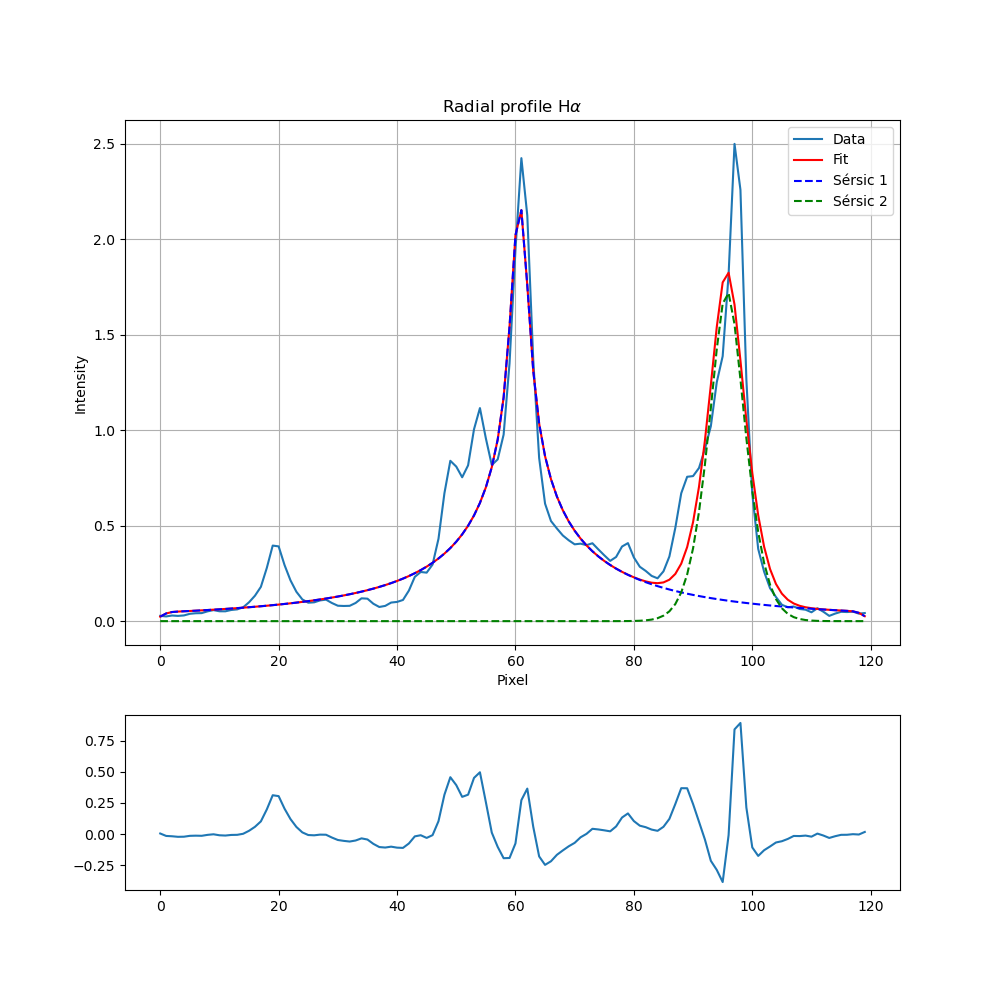

In [13]:
# Plots:
params_curve_2, covariance_2 = curve_fit(lambda x, *params: model_convolved(x, *params), x_axes, radial_profile_HA, p0=best_params2, sigma = radial_profile_error_HA)

print("Optimize parameters with curve fit:")

chi_quadr[1], red_chi[1] = save_params(params_curve_2, covariance_2, radial_profile_HA, radial_profile_error_HA,
    x_axes, 2, line_name="Two", output_prefix="fit")

aic[1] = AIC(x_axes, radial_profile_HA, chi_quadr[1], params_curve_2)
bic[1] = BIC(x_axes, radial_profile_HA, chi_quadr[1], params_curve_2)
print(aic[1], chi_quadr[1], bic[1], len(params_curve_2))

# Plots:
xgrid = np.linspace(min(x_axes), max(x_axes), 120)
y_fit = model_convolved(xgrid, *params_curve_2)

fig, ax = plt.subplots(2, 1, figsize=(10, 10), height_ratios=[3, 1])

ax[0].plot(x_axes, radial_profile_HA, label='Data')
ax[0].plot(xgrid, y_fit, 'r-', label='Fit')
ax[0].plot(xgrid, sersic_1d_convolved(xgrid, *params_curve_2[0:4]), 'b--', label='Sérsic 1')
ax[0].plot(xgrid, sersic_1d_convolved(xgrid, *params_curve_2[4:8]), 'g--', label='Sérsic 2')

ax[0].set_xlabel("Pixel")
ax[0].set_ylabel("Intensity")
ax[0].set_title(r"Radial profile H$\alpha$")
ax[0].legend()
ax[0].grid(True)
#ax[0].tight_layout()

ax[1].plot(x_axes, radial_profile_HA - y_fit)
#ax[1].set_ylim(-0.2, 0.2)

plt.savefig('AIC_2', bbox_inches='tight')

In [14]:
def model_convolved(x, *params):
    x_hr = np.linspace(min(x), max(x), 4000)
    profile = (
        sersic_1d(x_hr, *params[0:4]) +
        sersic_1d(x_hr, *params[4:8]) +
        sersic_1d(x_hr, *params[8:12])
        )
    kernel = Gaussian1DKernel(stddev=(sigma*len(x_hr))/len(x), x_size=len(x_hr), mode='center')   
    conv_profile = convolve(profile, kernel, mode='same')
    conv_profile_out = np.interp(x, x_hr, conv_profile)
    return conv_profile_out

def chi_squared(params, x, y_obs): #per diff evolution
    y_model = model_convolved(x, *params)
    return np.sum((y_obs - y_model)**2)

# Bounds:
bounds = [
    (0, 10),    # I_e: da 0 a 10 (o un valore ragionevole)
    (0, 50),  # r_e: da 0.1 a 50
    (0.1, 10),  # n: da 0.1 a 10
    (58, 63),   # x_0: posizione da 0 a 100

    (0, 10),
    (0, 50),
    (0.1, 10),
    (95, 100),

    (0, 10),
    (0, 50),
    (0.1, 10),
    (18, 23),
]
# objective function for differential_evolution
def objective(params):
    return chi_squared(params, x_axes, radial_profile_HA)

# Global fit:
result = differential_evolution(
    objective,
    bounds,
    strategy='best1bin',
    maxiter=1000,
    popsize=20,
    tol=1e-6,
    disp=True,
    polish=True
)

best_params3 = result.x

print("Optimize parameters with differential_evolution:", best_params3)

print("Chi quadro minimo:", result.fun)

differential_evolution step 1: f(x)= 891.597264721205
differential_evolution step 2: f(x)= 891.597264721205
differential_evolution step 3: f(x)= 891.597264721205
differential_evolution step 4: f(x)= 891.597264721205
differential_evolution step 5: f(x)= 45.79389020596453
differential_evolution step 6: f(x)= 45.79389020596453
differential_evolution step 7: f(x)= 45.79389020596453
differential_evolution step 8: f(x)= 45.79389020596453
differential_evolution step 9: f(x)= 42.44899010258017
differential_evolution step 10: f(x)= 35.491619261108525
differential_evolution step 11: f(x)= 30.653820865600405
differential_evolution step 12: f(x)= 30.653820865600405
differential_evolution step 13: f(x)= 18.49552501911143
differential_evolution step 14: f(x)= 18.49552501911143
differential_evolution step 15: f(x)= 7.521681736177389
differential_evolution step 16: f(x)= 7.521681736177389
differential_evolution step 17: f(x)= 7.521681736177389
differential_evolution step 18: f(x)= 7.521681736177389
di

C:\Users\ISAFA\AppData\Local\Temp\ipykernel_12308\111436280.py:9: RuntimeWarning: invalid value encountered in power
  return I_e * np.exp(-b_n * ((r / r_e)**(1 / n) - 1))
C:\Users\ISAFA\AppData\Local\Temp\ipykernel_12308\2235817546.py:9: RuntimeWarning: Use of fft convolution on input with NAN or inf results in NAN or inf output. Consider using method='direct' instead.
  conv_profile = convolve(profile, kernel, mode='same')


Optimize parameters with curve fit:
Sérsic 1: I_e=0.0531, r_e=47.9407, n=2.3257, x_0=60.6457
Sérsic 2: I_e=0.6367, r_e=4.3262, n=0.7359, x_0=95.7864
Sérsic 3: I_e=0.1065, r_e=2.4684, n=0.9346, x_0=19.5124
[4.13110480e-02 2.58226097e+01 6.85612833e-01 1.46978004e-02
 1.35660732e-01 4.94926292e-01 1.60739557e-01 2.22660221e-01
 1.84883462e-01 2.28829789e+00 1.41014755e+00 4.99239427e-01]
164.40110981586554
191.31699766633284 164.40110981586554 221.8510107292501 12


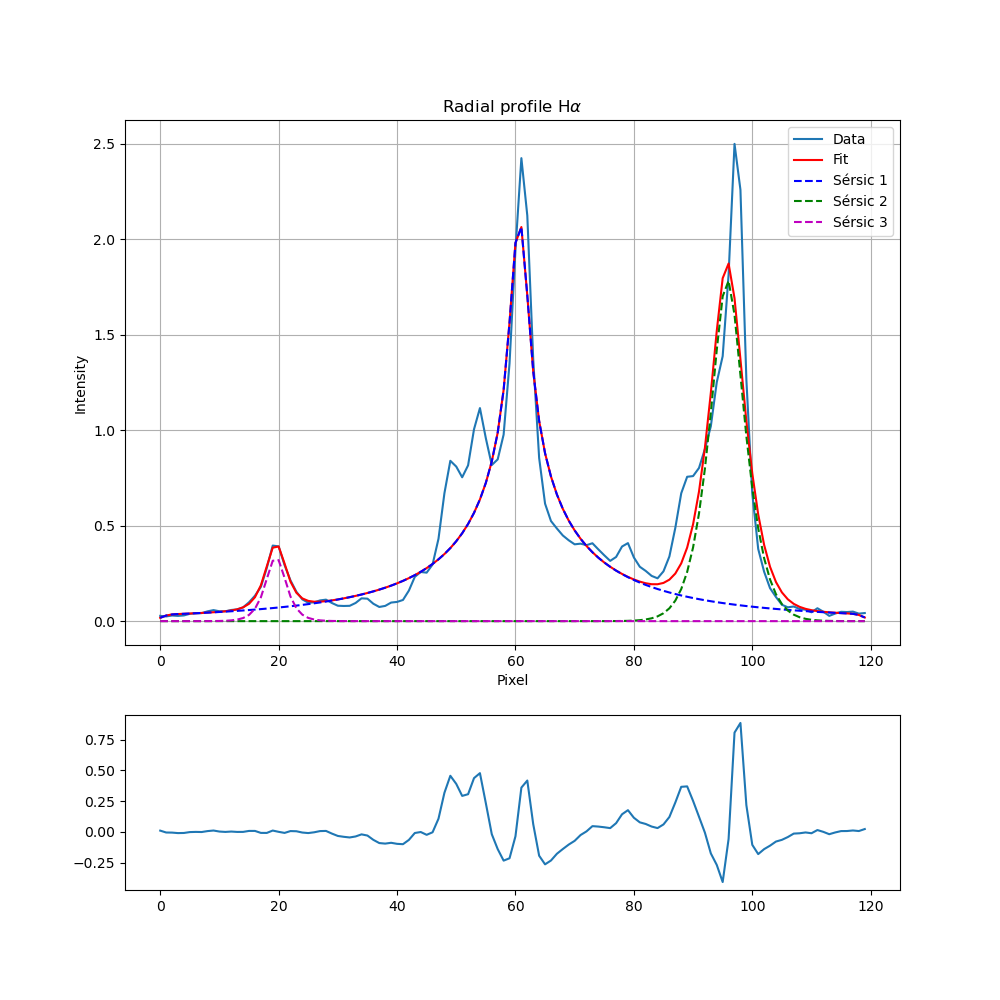

In [15]:
# Plots:
params_curve_3, covariance_3 = curve_fit(lambda x, *params: model_convolved(x, *params), x_axes, radial_profile_HA, p0=best_params3, sigma = radial_profile_error_HA)

print("Optimize parameters with curve fit:")

chi_quadr[2], red_chi[2] = save_params(params_curve_3, covariance_3, radial_profile_HA, radial_profile_error_HA,x_axes, 3,  
                                       line_name="Three", output_prefix="fit")

aic[2] = AIC(x_axes, radial_profile_HA, chi_quadr[2], params_curve_3)
bic[2] = BIC(x_axes, radial_profile_HA, chi_quadr[2], params_curve_3)
print(aic[2], chi_quadr[2], bic[2], len(params_curve_3))

# Plots:
xgrid = np.linspace(min(x_axes), max(x_axes), 120)
y_fit = model_convolved(xgrid, *params_curve_3)

fig, ax = plt.subplots(2, 1, figsize=(10, 10), height_ratios=[3, 1])

ax[0].plot(x_axes, radial_profile_HA, label='Data')
ax[0].plot(xgrid, y_fit, 'r-', label='Fit')
ax[0].plot(xgrid, sersic_1d_convolved(xgrid, *params_curve_3[0:4]), 'b--', label='Sérsic 1')
ax[0].plot(xgrid, sersic_1d_convolved(xgrid, *params_curve_3[4:8]), 'g--', label='Sérsic 2')
ax[0].plot(xgrid, sersic_1d_convolved(xgrid, *params_curve_3[8:12]), 'm--', label='Sérsic 3')

ax[0].set_xlabel("Pixel")
ax[0].set_ylabel("Intensity")
ax[0].set_title(r"Radial profile H$\alpha$")
ax[0].legend()
ax[0].grid(True)
#ax[0].tight_layout()

ax[1].plot(x_axes, radial_profile_HA - y_fit)
#ax[1].set_ylim(-0.2, 0.2)

plt.savefig('AIC_3', bbox_inches='tight')

In [16]:
def model_convolved(x, *params):
    x_hr = np.linspace(min(x), max(x), 4000)
    profile = (
        sersic_1d(x_hr, *params[0:4]) +
        sersic_1d(x_hr, *params[4:8]) +
        sersic_1d(x_hr, *params[8:12]) +
        sersic_1d(x_hr, *params[12:16])
    )
    kernel = Gaussian1DKernel(stddev=(sigma*len(x_hr))/len(x), x_size=len(x_hr), mode='center')   
    conv_profile = convolve(profile, kernel, mode='same')
    conv_profile_out = np.interp(x, x_hr, conv_profile)
    return conv_profile_out

def chi_squared(params, x, y_obs): #per diff evolution
    y_model = model_convolved(x, *params)
    return np.sum((y_obs - y_model)**2)

# Bounds:
bounds = [
    (0, 10),    # I_e: da 0 a 10 (o un valore ragionevole)
    (0, 50),  # r_e: da 0.1 a 50
    (0.1, 10),  # n: da 0.1 a 10
    (58, 63),   # x_0: posizione da 0 a 100

    (0, 10),
    (0, 50),
    (0.1, 10),
    (95, 100),

    (0, 10),
    (0, 50),
    (0.1, 10),
    (18, 23),

    (0, 10),    # I_e: da 0 a 10 (o un valore ragionevole)
    (0, 50),  # r_e: da 0.1 a 50
    (0.1, 10),  # n: da 0.1 a 10
    (45, 51),   # x_0: posizione da 0 a 100
]
# objective function for differential_evolution
def objective(params):
    return chi_squared(params, x_axes, radial_profile_HA)

# Global fit:
result = differential_evolution(
    objective,
    bounds,
    strategy='best1bin',
    maxiter=1000,
    popsize=20,
    tol=1e-6,
    disp=True,
    polish=True
)

best_params4 = result.x

print("Optimize parameters with differential_evolution:", best_params4)

print("Chi quadro minimo:", result.fun)

differential_evolution step 1: f(x)= 9007.881318408647
differential_evolution step 2: f(x)= 5778.931207036545
differential_evolution step 3: f(x)= 5778.931207036545
differential_evolution step 4: f(x)= 3689.614543044701
differential_evolution step 5: f(x)= 2246.384112856899
differential_evolution step 6: f(x)= 2246.384112856899
differential_evolution step 7: f(x)= 535.4849048213123
differential_evolution step 8: f(x)= 60.48854501111657
differential_evolution step 9: f(x)= 60.48854501111657
differential_evolution step 10: f(x)= 60.48854501111657
differential_evolution step 11: f(x)= 60.48854501111657
differential_evolution step 12: f(x)= 27.232606999525572
differential_evolution step 13: f(x)= 27.232606999525572
differential_evolution step 14: f(x)= 27.232606999525572
differential_evolution step 15: f(x)= 27.232606999525572
differential_evolution step 16: f(x)= 19.571900489847387
differential_evolution step 17: f(x)= 19.571900489847387
differential_evolution step 18: f(x)= 19.5719004898

C:\Users\ISAFA\AppData\Local\Temp\ipykernel_12308\111436280.py:9: RuntimeWarning: invalid value encountered in power
  return I_e * np.exp(-b_n * ((r / r_e)**(1 / n) - 1))
C:\Users\ISAFA\AppData\Local\Temp\ipykernel_12308\3655637262.py:10: RuntimeWarning: Use of fft convolution on input with NAN or inf results in NAN or inf output. Consider using method='direct' instead.
  conv_profile = convolve(profile, kernel, mode='same')


Optimize parameters with curve fit:
Sérsic 1: I_e=0.0097, r_e=143.2412, n=3.6489, x_0=61.0028
Sérsic 2: I_e=0.6467, r_e=4.3642, n=0.7072, x_0=95.6780
Sérsic 3: I_e=0.1095, r_e=2.4032, n=0.9133, x_0=19.5398
Sérsic 4: I_e=0.0815, r_e=4.3970, n=0.0319, x_0=51.5121
[1.62132666e-02 1.70878340e+02 1.47966709e+00 4.88066649e-04
 1.06720912e-01 3.82021431e-01 1.23610349e-01 1.83718916e-01
 1.52352576e-01 1.75766684e+00 1.13178768e+00 4.02066669e-01
 6.56459201e+00 3.09835310e+00 6.76878240e-01 3.77850246e-01]
106.24130778219768
143.52286118025594 106.24130778219768 182.8411756667104 16


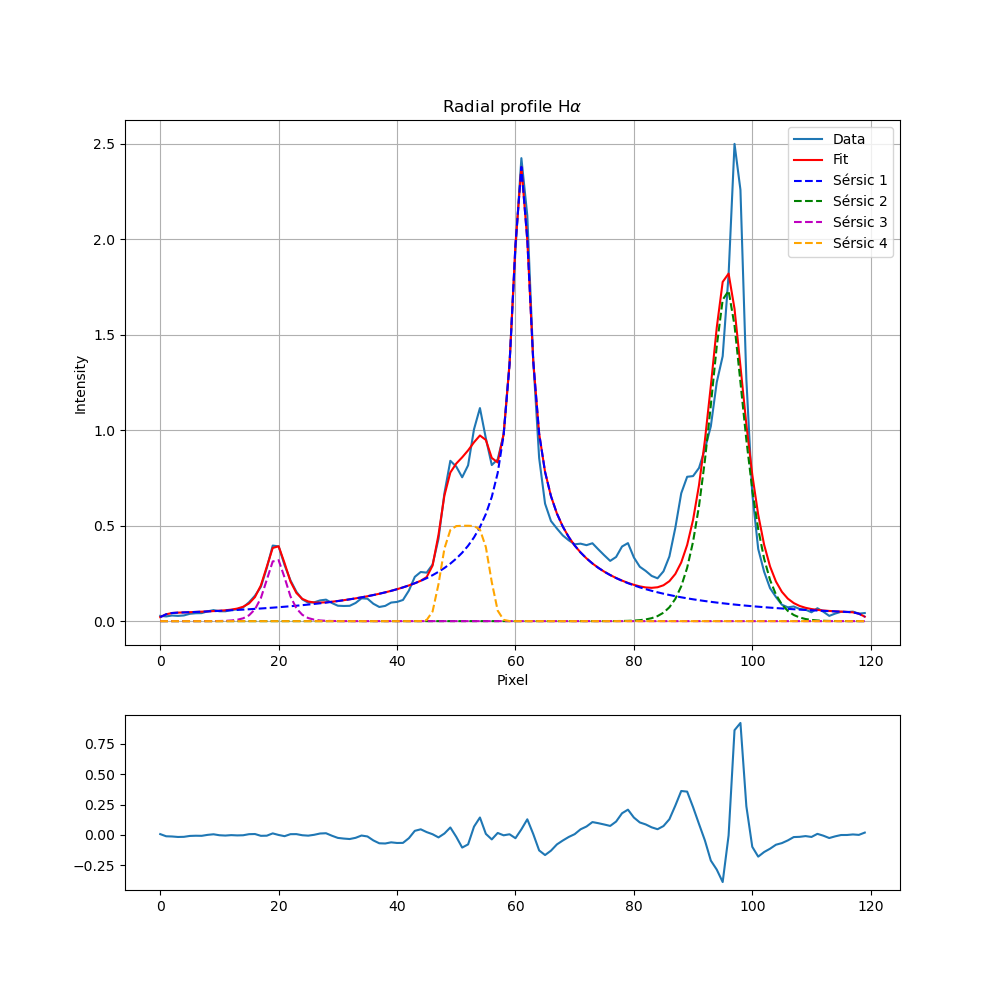

In [17]:
# Plots:
params_curve_4, covariance_4 = curve_fit(lambda x, *params: model_convolved(x, *params), x_axes, radial_profile_HA, p0=best_params4, sigma = radial_profile_error_HA)

print("Optimize parameters with curve fit:")

chi_quadr[3], red_chi[3] = save_params(params_curve_4, covariance_4, radial_profile_HA, radial_profile_error_HA, x_axes, 4, line_name="Four", output_prefix="fit")

aic[3] = AIC(x_axes, radial_profile_HA, chi_quadr[3], params_curve_4)
bic[3] = BIC(x_axes, radial_profile_HA, chi_quadr[3], params_curve_4)
print(aic[3], chi_quadr[3], bic[3], len(params_curve_4))

# Plots:
xgrid = np.linspace(min(x_axes), max(x_axes), 120)
y_fit = model_convolved(xgrid, *params_curve_4)

fig, ax = plt.subplots(2, 1, figsize=(10, 10), height_ratios=[3, 1])

ax[0].plot(x_axes, radial_profile_HA, label='Data')
ax[0].plot(xgrid, y_fit, 'r-', label='Fit')
ax[0].plot(xgrid, sersic_1d_convolved(xgrid, *params_curve_4[0:4]), 'b--', label='Sérsic 1')
ax[0].plot(xgrid, sersic_1d_convolved(xgrid, *params_curve_4[4:8]), 'g--', label='Sérsic 2')
ax[0].plot(xgrid, sersic_1d_convolved(xgrid, *params_curve_4[8:12]), 'm--', label='Sérsic 3')
ax[0].plot(xgrid, sersic_1d_convolved(xgrid, *params_curve_4[12:16]), color='orange', linestyle='--', label='Sérsic 4')

ax[0].set_xlabel("Pixel")
ax[0].set_ylabel("Intensity")
ax[0].set_title(r"Radial profile H$\alpha$")
ax[0].legend()
ax[0].grid(True)
#ax[0].tight_layout()

ax[1].plot(x_axes, radial_profile_HA - y_fit)
#ax[1].set_ylim(-0.2, 0.2)

plt.savefig('AIC_4', bbox_inches='tight')

In [22]:
def model_convolved(x, *params):
    x_hr = np.linspace(min(x), max(x), 4000)
    profile = (
        sersic_1d(x_hr, *params[0:4]) +
        sersic_1d(x_hr, *params[4:8]) +
        sersic_1d(x_hr, *params[8:12]) +
        sersic_1d(x_hr, *params[12:16]) +
        sersic_1d(x_hr, *params[16:20])
    )
    kernel = Gaussian1DKernel(stddev=(sigma*len(x_hr))/len(x), x_size=len(x_hr), mode='center')   
    conv_profile = convolve(profile, kernel, mode='same')
    conv_profile_out = np.interp(x, x_hr, conv_profile)
    return conv_profile_out

def chi_squared(params, x, y_obs): #per diff evolution
    y_model = model_convolved(x, *params)
    return np.sum((y_obs - y_model)**2)

# Bounds:
bounds = [
    (0, 10),    # I_e: da 0 a 10 (o un valore ragionevole)
    (0, 50),  # r_e: da 0.1 a 50
    (0.1, 10),  # n: da 0.1 a 10
    (58, 63),   # x_0: posizione da 0 a 100

    (0, 10),
    (0, 50),
    (0.1, 10),
    (95, 100),

    (0, 10),
    (0, 50),
    (0.1, 10),
    (18, 23),

    (0, 10),    # I_e: da 0 a 10 (o un valore ragionevole)
    (0, 50),  # r_e: da 0.1 a 50
    (0.1, 10),  # n: da 0.1 a 10
    (48, 50),    # x_0: posizione da 0 a 100
    
    (0, 10),    # I_e: da 0 a 10 (o un valore ragionevole)
    (0, 50),  # r_e: da 0.1 a 50
    (0.1, 10),  # n: da 0.1 a 10
    (52, 54),   # x_0: posizione da 0 a 100
]
# objective function for differential_evolution
def objective(params):
    return chi_squared(params, x_axes, radial_profile_HA)

# Global fit:
result = differential_evolution(
    objective,
    bounds,
    strategy='best1bin',
    maxiter=1000,
    popsize=20,
    tol=1e-6,
    disp=True,
    polish=True
)

best_params5 = result.x

print("Optimize parameters with differential_evolution:", best_params5)

print("Chi quadro minimo:", result.fun)

differential_evolution step 1: f(x)= 17174.334388749412
differential_evolution step 2: f(x)= 17174.334388749412
differential_evolution step 3: f(x)= 17174.334388749412
differential_evolution step 4: f(x)= 17174.334388749412
differential_evolution step 5: f(x)= 2686.633155944758
differential_evolution step 6: f(x)= 2686.633155944758
differential_evolution step 7: f(x)= 2686.633155944758
differential_evolution step 8: f(x)= 2686.633155944758
differential_evolution step 9: f(x)= 2686.633155944758
differential_evolution step 10: f(x)= 2674.3869252467293
differential_evolution step 11: f(x)= 2674.3869252467293
differential_evolution step 12: f(x)= 2674.3869252467293
differential_evolution step 13: f(x)= 2674.3869252467293
differential_evolution step 14: f(x)= 1281.8974661699892
differential_evolution step 15: f(x)= 754.3024835585835
differential_evolution step 16: f(x)= 754.3024835585835
differential_evolution step 17: f(x)= 754.3024835585835
differential_evolution step 18: f(x)= 691.145591

Optimize parameters with curve fit:
Sérsic 1: I_e=0.0555, r_e=24.3693, n=2.5491, x_0=61.0325
Sérsic 2: I_e=0.2493, r_e=7.1219, n=1.5344, x_0=96.3852
Sérsic 3: I_e=0.1814, r_e=1.4894, n=0.5269, x_0=19.5674
Sérsic 4: I_e=0.0784, r_e=37.8572, n=0.1000, x_0=50.0000
Sérsic 5: I_e=0.4763, r_e=3.6559, n=0.1183, x_0=52.0000
[1.45386010e-01 4.86659501e+01 2.29926768e+00 1.95251038e-02
 1.36453081e-01 2.47052125e+00 3.99943520e-01 1.78178925e-01
 3.53881148e-01 1.07152991e+00 1.60459767e+00 4.21802012e-01
 7.53759569e-02 2.10627650e+01 1.32443778e-01 1.17749748e+01
 1.58917808e-01 2.64061063e+00 2.48898771e-01 4.28515660e-01]
110.73885191314615
159.22370039799466 110.73885191314615 206.48868676878706 20


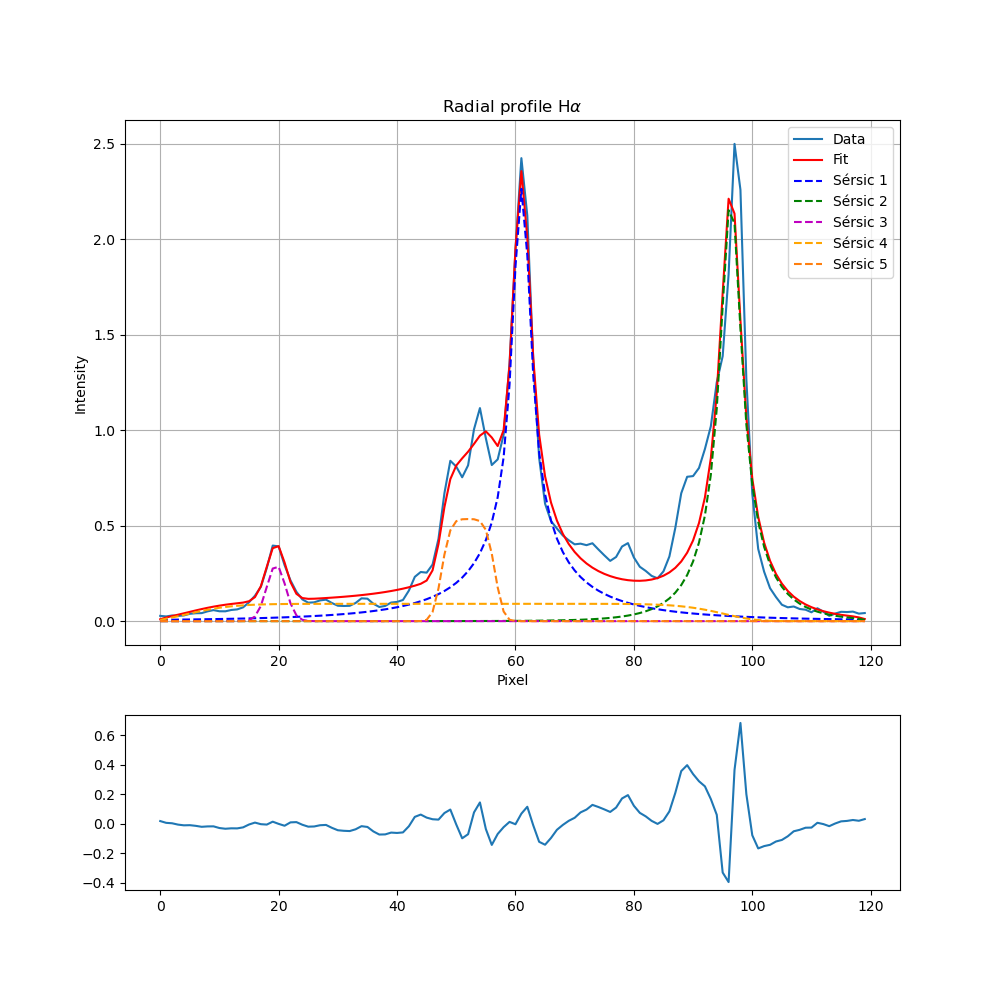

In [23]:
# Plots:
lower_bounds, upper_bounds = zip(*bounds)
bounds_list = (list(lower_bounds), list(upper_bounds))
params_curve_5, covariance_5 = curve_fit(lambda x, *params: model_convolved(x, *params), x_axes, radial_profile_HA, 
                                         p0=best_params5, sigma = radial_profile_error_HA, maxfev = 10000, bounds = bounds_list)

print("Optimize parameters with curve fit:")

chi_quadr[4], red_chi[4] = save_params(params_curve_5, covariance_5, radial_profile_HA, radial_profile_error_HA, x_axes, 5, line_name="Five", output_prefix="fit")

aic[4] = AIC(x_axes, radial_profile_HA, chi_quadr[4], params_curve_5)
bic[4] = BIC(x_axes, radial_profile_HA, chi_quadr[4], params_curve_5)
print(aic[4], chi_quadr[4], bic[4], len(params_curve_5))

# Plots:
xgrid = np.linspace(min(x_axes), max(x_axes), 120)
y_fit = model_convolved(xgrid, *params_curve_5)

fig, ax = plt.subplots(2, 1, figsize=(10, 10), height_ratios=[3, 1])

ax[0].plot(x_axes, radial_profile_HA, label='Data')
ax[0].plot(xgrid, y_fit, 'r-', label='Fit')
ax[0].plot(xgrid, sersic_1d_convolved(xgrid, *params_curve_5[0:4]), 'b--', label='Sérsic 1')
ax[0].plot(xgrid, sersic_1d_convolved(xgrid, *params_curve_5[4:8]), 'g--', label='Sérsic 2')
ax[0].plot(xgrid, sersic_1d_convolved(xgrid, *params_curve_5[8:12]), 'm--', label='Sérsic 3')
ax[0].plot(xgrid, sersic_1d_convolved(xgrid, *params_curve_5[12:16]), color='orange', linestyle='--', label='Sérsic 4')
ax[0].plot(xgrid, sersic_1d_convolved(xgrid, *params_curve_5[16:20]),  linestyle='--', label='Sérsic 5')

ax[0].set_xlabel("Pixel")
ax[0].set_ylabel("Intensity")
ax[0].set_title(r"Radial profile H$\alpha$")
ax[0].legend()
ax[0].grid(True)
#ax[0].tight_layout()

ax[1].plot(x_axes, radial_profile_HA - y_fit)
#ax[1].set_ylim(-0.2, 0.2)
plt.savefig('AIC_5', bbox_inches='tight')

In [24]:
def model_convolved(x, *params):
    x_hr = np.linspace(min(x), max(x), 4000)
    profile = (
        sersic_1d(x_hr, *params[0:4]) +
        sersic_1d(x_hr, *params[4:8]) +
        sersic_1d(x_hr, *params[8:12]) +
        sersic_1d(x_hr, *params[12:16]) +
        sersic_1d(x_hr, *params[16:20]) +
        sersic_1d(x_hr, *params[20:24])
    )
    kernel = Gaussian1DKernel(stddev=(sigma*len(x_hr))/len(x), x_size=len(x_hr), mode='center')   
    conv_profile = convolve(profile, kernel, mode='same')
    conv_profile_out = np.interp(x, x_hr, conv_profile)
    return conv_profile_out

def chi_squared(params, x, y_obs): #per diff evolution
    y_model = model_convolved(x, *params)
    return np.sum((y_obs - y_model)**2)

# Bounds:
bounds =[
    (0, 10),    # I_e: da 0 a 10 (o un valore ragionevole)
    (0, 50),  # r_e: da 0.1 a 50
    (0.1, 10),  # n: da 0.1 a 10
    (58, 63),   # x_0: posizione da 0 a 100

    (0, 10),
    (0, 50),
    (0.1, 10),
    (95, 100),

    (0, 10),
    (0, 50),
    (0.1, 10),
    (18, 23),

    (0, 10),    # I_e: da 0 a 10 (o un valore ragionevole)
    (0, 50),  # r_e: da 0.1 a 50
    (0.1, 10),  # n: da 0.1 a 10
    (45, 51),    # x_0: posizione da 0 a 100
    
    (0, 10),    # I_e: da 0 a 10 (o un valore ragionevole)
    (0, 50),  # r_e: da 0.1 a 50
    (0.1, 10),  # n: da 0.1 a 10
    (52, 56),   # x_0: posizione da 0 a 100

    (0, 10),    # I_e: da 0 a 10 (o un valore ragionevole)
    (0, 50),  # r_e: da 0.1 a 50
    (0.1, 10),  # n: da 0.1 a 10
    (77, 82)   # x_0: posizione da 0 a 100
]
# objective function for differential_evolution
def objective(params):
    return chi_squared(params, x_axes, radial_profile_HA)

# Global fit:
result = differential_evolution(
    objective,
    bounds,
    strategy='best1bin',
    maxiter=1000,
    popsize=20,
    tol=1e-6,
    disp=True,
    polish=True
)

best_params6 = result.x

print("Optimize parameters with differential_evolution:", best_params6)

print("Chi quadro minimo:", result.fun)

differential_evolution step 1: f(x)= 80217.01759354693
differential_evolution step 2: f(x)= 80217.01759354693
differential_evolution step 3: f(x)= 41967.05793638843
differential_evolution step 4: f(x)= 33968.275259494025
differential_evolution step 5: f(x)= 23893.378282458812
differential_evolution step 6: f(x)= 23893.378282458812
differential_evolution step 7: f(x)= 22309.501411465222
differential_evolution step 8: f(x)= 15210.527961005168
differential_evolution step 9: f(x)= 15210.527961005168
differential_evolution step 10: f(x)= 12841.674522764246
differential_evolution step 11: f(x)= 9249.911104064231
differential_evolution step 12: f(x)= 7317.66564526504
differential_evolution step 13: f(x)= 7317.66564526504
differential_evolution step 14: f(x)= 7317.66564526504
differential_evolution step 15: f(x)= 7317.66564526504
differential_evolution step 16: f(x)= 7317.66564526504
differential_evolution step 17: f(x)= 7317.66564526504
differential_evolution step 18: f(x)= 7317.66564526504
d

C:\Users\ISAFA\AppData\Local\Temp\ipykernel_12308\111436280.py:9: RuntimeWarning: overflow encountered in exp
  return I_e * np.exp(-b_n * ((r / r_e)**(1 / n) - 1))
C:\Users\ISAFA\anaconda3\Lib\site-packages\scipy\signal\_signaltools.py:568: RuntimeWarning: invalid value encountered in multiply
  ret = ifft(sp1 * sp2, fshape, axes=axes)
C:\Users\ISAFA\AppData\Local\Temp\ipykernel_12308\23254914.py:12: RuntimeWarning: Use of fft convolution on input with NAN or inf results in NAN or inf output. Consider using method='direct' instead.
  conv_profile = convolve(profile, kernel, mode='same')


Optimize parameters with curve fit:
Sérsic 1: I_e=0.5595, r_e=2.6975, n=1.0932, x_0=61.1541
Sérsic 2: I_e=0.2525, r_e=5.7214, n=1.5482, x_0=96.8697
Sérsic 3: I_e=0.0092, r_e=27.1652, n=2.5517, x_0=19.6102
Sérsic 4: I_e=0.4236, r_e=0.8362, n=0.3091, x_0=48.9047
Sérsic 5: I_e=0.1037, r_e=14.1756, n=1.4780, x_0=53.6522
Sérsic 6: I_e=0.1423, r_e=16.8395, n=0.0471, x_0=82.0950
[3.97874953e-01 1.32307076e+00 5.29724036e-01 1.09903808e-01
 9.63480446e-02 1.21417653e+00 2.78571662e-01 2.03015397e-01
 3.50107111e-02 7.34050732e+01 3.49244940e+00 2.61724010e-02
 3.20618956e+00 8.03184098e-01 6.76615466e+00 3.09710594e-01
 8.32639563e-02 7.14626130e+00 5.25634156e-01 4.13647623e-01
 4.70618139e-01 4.00475905e+00 8.96749617e-02 1.44796939e+00]
47.86381178645416
108.49539073382259 47.86381178645416 162.76361361322327 24


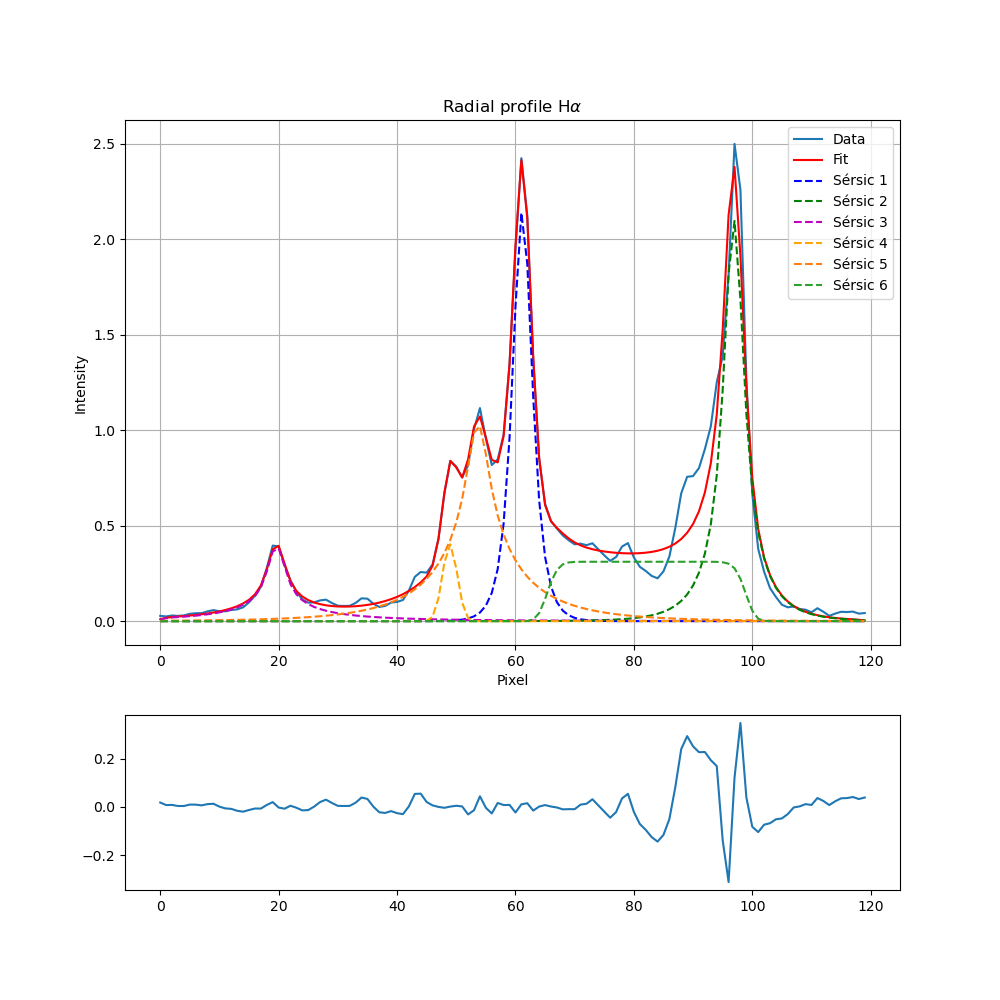

In [25]:
# Plots:
params_curve_6, covariance_6 = curve_fit(lambda x, *params: model_convolved(x, *params), x_axes, radial_profile_HA, p0=best_params6, sigma = radial_profile_error_HA)

print("Optimize parameters with curve fit:")

chi_quadr[5], red_chi[5] = save_params(params_curve_6, covariance_6, radial_profile_HA, radial_profile_error_HA, x_axes, 6, line_name="Six", output_prefix="fit")

aic[5] = AIC(x_axes, radial_profile_HA, chi_quadr[5], params_curve_6)
bic[5] = BIC(x_axes, radial_profile_HA, chi_quadr[5], params_curve_6)
print(aic[5], chi_quadr[5], bic[5], len(best_params6))

# Plots:
xgrid = np.linspace(min(x_axes), max(x_axes), 120)
y_fit = model_convolved(xgrid, *params_curve_6)

fig, ax = plt.subplots(2, 1, figsize=(10, 10), height_ratios=[3, 1])

ax[0].plot(x_axes, radial_profile_HA, label='Data')
ax[0].plot(xgrid, y_fit, 'r-', label='Fit')
ax[0].plot(xgrid, sersic_1d_convolved(xgrid, *params_curve_6[0:4]), 'b--', label='Sérsic 1')
ax[0].plot(xgrid, sersic_1d_convolved(xgrid, *params_curve_6[4:8]), 'g--', label='Sérsic 2')
ax[0].plot(xgrid, sersic_1d_convolved(xgrid, *params_curve_6[8:12]), 'm--', label='Sérsic 3')
ax[0].plot(xgrid, sersic_1d_convolved(xgrid, *params_curve_6[12:16]), color='orange', linestyle='--', label='Sérsic 4')
ax[0].plot(xgrid, sersic_1d_convolved(xgrid, *params_curve_6[16:20]),  linestyle='--', label='Sérsic 5')
ax[0].plot(xgrid, sersic_1d_convolved(xgrid, *params_curve_6[20:24]),  linestyle='--', label='Sérsic 6')

ax[0].set_xlabel("Pixel")
ax[0].set_ylabel("Intensity")
ax[0].set_title(r"Radial profile H$\alpha$")
ax[0].legend()
ax[0].grid(True)
#ax[0].tight_layout()

ax[1].plot(x_axes, radial_profile_HA - y_fit)

plt.savefig('AIC_6', bbox_inches='tight')

In [26]:
def model_convolved(x, *params):
    x_hr = np.linspace(min(x), max(x), 4000)
    profile = (
        sersic_1d(x_hr, *params[0:4]) +
        sersic_1d(x_hr, *params[4:8]) +
        sersic_1d(x_hr, *params[8:12]) +
        sersic_1d(x_hr, *params[12:16]) +
        sersic_1d(x_hr, *params[16:20]) +
        sersic_1d(x_hr, *params[20:24]) +
        sersic_1d(x_hr, *params[24:28])
    )
    kernel = Gaussian1DKernel(stddev=(sigma*len(x_hr))/len(x), x_size=len(x_hr), mode='center')   
    conv_profile = convolve(profile, kernel, mode='same')
    conv_profile_out = np.interp(x, x_hr, conv_profile)
    return conv_profile_out

def chi_squared(params, x, y_obs): #per diff evolution
    y_model = model_convolved(x, *params)
    return np.sum((y_obs - y_model)**2)

# Bounds:
bounds =[
     (0, 10),    # I_e: da 0 a 10 (o un valore ragionevole)
    (0, 50),  # r_e: da 0.1 a 50
    (0.1, 10),  # n: da 0.1 a 10
    (58, 63),   # x_0: posizione da 0 a 100

    (0, 10),
    (0, 50),
    (0.1, 10),
    (95, 100),

    (0, 10),
    (0, 50),
    (0.1, 10),
    (18, 23),

    (0, 10),    # I_e: da 0 a 10 (o un valore ragionevole)
    (0, 50),  # r_e: da 0.1 a 50
    (0.1, 10),  # n: da 0.1 a 10
    (45, 51),    # x_0: posizione da 0 a 100
    
    (0, 10),    # I_e: da 0 a 10 (o un valore ragionevole)
    (0, 50),  # r_e: da 0.1 a 50
    (0.1, 10),  # n: da 0.1 a 10
    (52, 56),   # x_0: posizione da 0 a 100

    (0, 10),    # I_e: da 0 a 10 (o un valore ragionevole)
    (0, 50),  # r_e: da 0.1 a 50
    (0.1, 10),  # n: da 0.1 a 10
    (77, 82),   # x_0: posizione da 0 a 100

    (0, 10),    # I_e: da 0 a 10 (o un valore ragionevole)
    (0, 50),  # r_e: da 0.1 a 50
    (0.1, 10),  # n: da 0.1 a 10
    (85, 90)
]
# objective function for differential_evolution
def objective(params):
    return chi_squared(params, x_axes, radial_profile_HA)

# Global fit:
result = differential_evolution(
    objective,
    bounds,
    strategy='best1bin',
    maxiter=1000,
    popsize=20,
    tol=1e-6,
    disp=True,
    polish=True
)

best_params7 = result.x

print("Optimize parameters with differential_evolution:", best_params7)

print("Chi quadro minimo:", result.fun)

differential_evolution step 1: f(x)= 236717.15381080995
differential_evolution step 2: f(x)= 131920.6272018486
differential_evolution step 3: f(x)= 91152.86056884137
differential_evolution step 4: f(x)= 41971.163496034394
differential_evolution step 5: f(x)= 33674.141639551395
differential_evolution step 6: f(x)= 33674.141639551395
differential_evolution step 7: f(x)= 29770.609173683755
differential_evolution step 8: f(x)= 29770.609173683755
differential_evolution step 9: f(x)= 24320.097976888384
differential_evolution step 10: f(x)= 16530.965009995663
differential_evolution step 11: f(x)= 16530.965009995663
differential_evolution step 12: f(x)= 16530.965009995663
differential_evolution step 13: f(x)= 4784.880776579674
differential_evolution step 14: f(x)= 4784.880776579674
differential_evolution step 15: f(x)= 4784.880776579674
differential_evolution step 16: f(x)= 4784.880776579674
differential_evolution step 17: f(x)= 4784.880776579674
differential_evolution step 18: f(x)= 4784.8807

C:\Users\ISAFA\AppData\Local\Temp\ipykernel_12308\111436280.py:9: RuntimeWarning: invalid value encountered in power
  return I_e * np.exp(-b_n * ((r / r_e)**(1 / n) - 1))
C:\Users\ISAFA\AppData\Local\Temp\ipykernel_12308\2944996234.py:13: RuntimeWarning: Use of fft convolution on input with NAN or inf results in NAN or inf output. Consider using method='direct' instead.
  conv_profile = convolve(profile, kernel, mode='same')


Optimize parameters with curve fit:
Sérsic 1: I_e=1.5492, r_e=1.0207, n=0.2676, x_0=61.1711
Sérsic 2: I_e=0.3438, r_e=3.1100, n=1.5183, x_0=97.3663
Sérsic 3: I_e=0.0337, r_e=5.6955, n=1.7988, x_0=19.5653
Sérsic 4: I_e=0.0464, r_e=48.8727, n=0.8016, x_0=62.6409
Sérsic 5: I_e=0.5513, r_e=6.3944, n=0.3185, x_0=55.2591
Sérsic 6: I_e=0.2130, r_e=7.8801, n=0.1670, x_0=72.4410
Sérsic 7: I_e=0.5603, r_e=3.8379, n=0.2427, x_0=91.8302
[ 1.25579181  0.18310699  0.80755839  0.0850106   0.19435827  0.81498382
  0.43599952  0.09523451  0.04287983  5.44336867  0.96750768  0.13731842
  0.0273193  17.10525019  0.69651396  5.00208719  0.06588755  0.62786788
  0.05545073  0.99440437  0.04573621  4.33380199  0.16119315  5.17899066
  0.07704898  0.79065924  0.09171535  1.08508689]
12.686775421263311
86.53292926741716 12.686775421263311 146.7365442191606 28


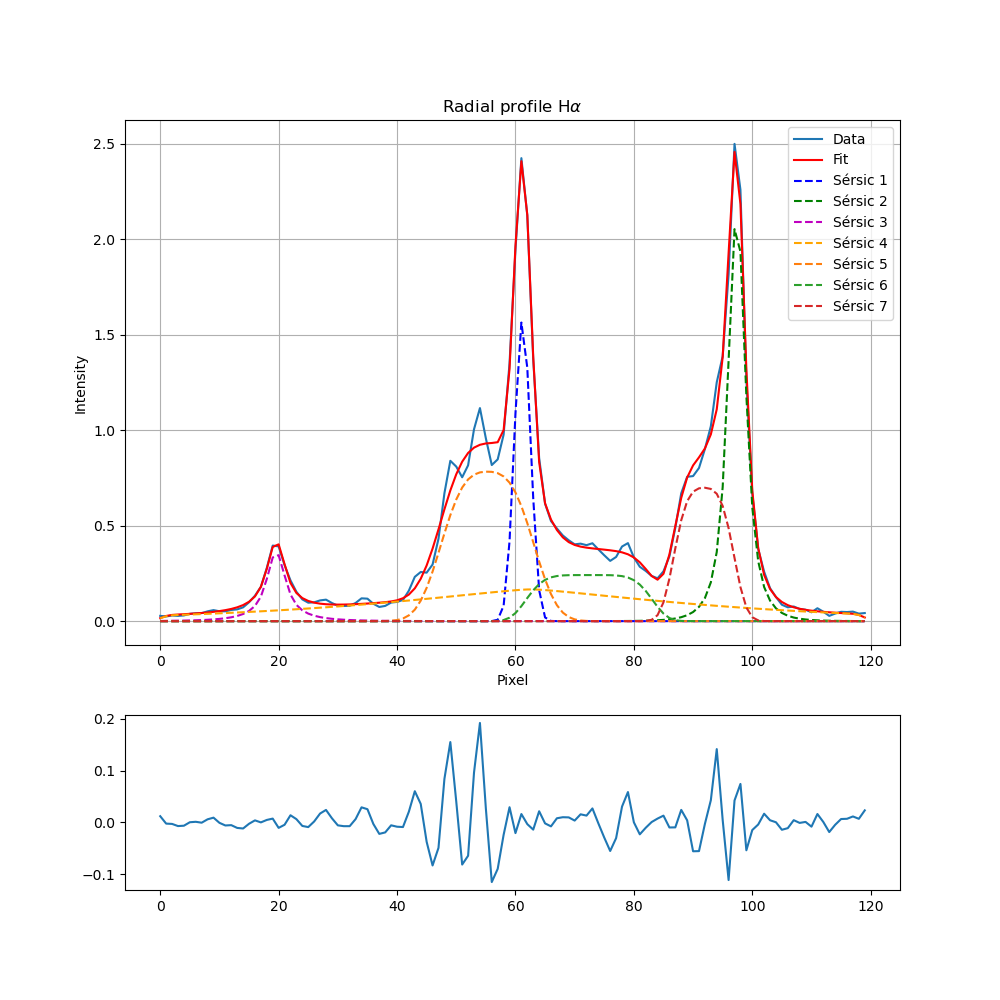

In [27]:
# Plots:
params_curve_7, covariance_7 = curve_fit(lambda x, *params: model_convolved(x, *params), x_axes, radial_profile_HA, p0=best_params7, sigma = radial_profile_error_HA)

print("Optimize parameters with curve fit:")

chi_quadr[6], red_chi[6] = save_params(params_curve_7, covariance_7, radial_profile_HA, radial_profile_error_HA, x_axes, 7, 
                                       line_name="Seven", output_prefix="fit")

aic[6] = AIC(x_axes, radial_profile_HA, chi_quadr[6], params_curve_7)
bic[6] = BIC(x_axes, radial_profile_HA, chi_quadr[6], params_curve_7)
print(aic[6], chi_quadr[6], bic[6], len(best_params7))

# Plots:
xgrid = np.linspace(min(x_axes), max(x_axes), 120)
y_fit = model_convolved(xgrid, *params_curve_7)

fig, ax = plt.subplots(2, 1, figsize=(10, 10), height_ratios=[3, 1])

ax[0].plot(x_axes, radial_profile_HA, label='Data')
ax[0].plot(xgrid, y_fit, 'r-', label='Fit')
ax[0].plot(xgrid, sersic_1d_convolved(xgrid, *params_curve_7[0:4]), 'b--', label='Sérsic 1')
ax[0].plot(xgrid, sersic_1d_convolved(xgrid, *params_curve_7[4:8]), 'g--', label='Sérsic 2')
ax[0].plot(xgrid, sersic_1d_convolved(xgrid, *params_curve_7[8:12]), 'm--', label='Sérsic 3')
ax[0].plot(xgrid, sersic_1d_convolved(xgrid, *params_curve_7[12:16]), color='orange', linestyle='--', label='Sérsic 4')
ax[0].plot(xgrid, sersic_1d_convolved(xgrid, *params_curve_7[16:20]),  linestyle='--', label='Sérsic 5')
ax[0].plot(xgrid, sersic_1d_convolved(xgrid, *params_curve_7[20:24]),  linestyle='--', label='Sérsic 6')
ax[0].plot(xgrid, sersic_1d_convolved(xgrid, *params_curve_7[24:28]),  linestyle='--', label='Sérsic 7')

ax[0].set_xlabel("Pixel")
ax[0].set_ylabel("Intensity")
ax[0].set_title(r"Radial profile H$\alpha$")
ax[0].legend()
ax[0].grid(True)

ax[1].plot(x_axes, radial_profile_HA - y_fit)

plt.savefig('AIC_7', bbox_inches='tight')

In [28]:
def model_convolved(x, *params):
    x_hr = np.linspace(min(x), max(x), 4000)
    profile = (
        sersic_1d(x_hr, *params[0:4]) +
        sersic_1d(x_hr, *params[4:8]) +
        sersic_1d(x_hr, *params[8:12]) +
        sersic_1d(x_hr, *params[12:16]) +
        sersic_1d(x_hr, *params[16:20]) +
        sersic_1d(x_hr, *params[20:24]) +
        sersic_1d(x_hr, *params[24:28]) +
        sersic_1d(x_hr, *params[28:32])
    )
    kernel = Gaussian1DKernel(stddev=(sigma*len(x_hr))/len(x), x_size=len(x_hr), mode='center')   
    conv_profile = convolve(profile, kernel, mode='same')
    conv_profile_out = np.interp(x, x_hr, conv_profile)
    return conv_profile_out

def chi_squared(params, x, y_obs): #per diff evolution
    y_model = model_convolved(x, *params)
    return np.sum((y_obs - y_model)**2)

# Bounds:
bounds =[
     (0, 10),    # I_e: da 0 a 10 (o un valore ragionevole)
    (0, 50),  # r_e: da 0.1 a 50
    (0.1, 10),  # n: da 0.1 a 10
    (58, 63),   # x_0: posizione da 0 a 100

    (0, 10),
    (0, 50),
    (0.1, 10),
    (95, 100),

    (0, 10),
    (0, 50),
    (0.1, 10),
    (18, 23),

    (0, 10),    # I_e: da 0 a 10 (o un valore ragionevole)
    (0, 50),  # r_e: da 0.1 a 50
    (0.1, 10),  # n: da 0.1 a 10
    (45, 51),    # x_0: posizione da 0 a 100
    
    (0, 10),    # I_e: da 0 a 10 (o un valore ragionevole)
    (0, 50),  # r_e: da 0.1 a 50
    (0.1, 10),  # n: da 0.1 a 10
    (52, 56),   # x_0: posizione da 0 a 100

    (0, 10),    # I_e: da 0 a 10 (o un valore ragionevole)
    (0, 50),  # r_e: da 0.1 a 50
    (0.1, 10),  # n: da 0.1 a 10
    (77, 82),   # x_0: posizione da 0 a 100

    (0, 10),    # I_e: da 0 a 10 (o un valore ragionevole)
    (0, 50),  # r_e: da 0.1 a 50
    (0.1, 10),  # n: da 0.1 a 10
    (85, 90),

    (0, 10),    # I_e: da 0 a 10 (o un valore ragionevole)
    (0, 50),  # r_e: da 0.1 a 50
    (0.1, 10),  # n: da 0.1 a 10
    (0, 100)
]
# objective function for differential_evolution
def objective(params):
    return chi_squared(params, x_axes, radial_profile_HA)

# Global fit:
result = differential_evolution(
    objective,
    bounds,
    strategy='best1bin',
    maxiter=1000,
    popsize=20,
    tol=1e-6,
    disp=True,
    polish=True
)

best_params8 = result.x

print("Optimize parameters with differential_evolution:", best_params8)

print("Chi quadro minimo:", result.fun)

differential_evolution step 1: f(x)= 80907.15684798763
differential_evolution step 2: f(x)= 80907.15684798763
differential_evolution step 3: f(x)= 80907.15684798763
differential_evolution step 4: f(x)= 80907.15684798763
differential_evolution step 5: f(x)= 36484.754216679634
differential_evolution step 6: f(x)= 36484.754216679634
differential_evolution step 7: f(x)= 36484.754216679634
differential_evolution step 8: f(x)= 36484.754216679634
differential_evolution step 9: f(x)= 36484.754216679634
differential_evolution step 10: f(x)= 17141.952063179928
differential_evolution step 11: f(x)= 17141.952063179928
differential_evolution step 12: f(x)= 17141.952063179928
differential_evolution step 13: f(x)= 17141.952063179928
differential_evolution step 14: f(x)= 17141.952063179928
differential_evolution step 15: f(x)= 17141.952063179928
differential_evolution step 16: f(x)= 14188.912521843919
differential_evolution step 17: f(x)= 14188.912521843919
differential_evolution step 18: f(x)= 14188.

C:\Users\ISAFA\AppData\Local\Temp\ipykernel_12308\111436280.py:9: RuntimeWarning: divide by zero encountered in divide
  return I_e * np.exp(-b_n * ((r / r_e)**(1 / n) - 1))


Optimize parameters with differential_evolution: [9.19221076e-01 1.63632863e+00 7.05945835e-01 6.10462707e+01
 5.55883431e-01 3.05768409e+00 1.14821941e+00 9.70680662e+01
 1.37610567e-01 2.59015822e+00 7.59221347e-01 1.95130683e+01
 4.70971657e-02 3.55901848e+00 1.91646314e+00 4.92163625e+01
 1.58963785e-02 3.33615909e+01 2.69792214e+00 5.40191363e+01
 1.31734214e+00 2.99275703e-04 7.82435395e+00 7.81727115e+01
 5.02432908e-01 3.17708480e+00 1.36340901e-01 9.00000000e+01
 1.04708451e-01 2.56656471e+01 8.74198298e-01 6.55711662e+01]
Chi quadro minimo: 0.29107684092505437


C:\Users\ISAFA\AppData\Local\Temp\ipykernel_12308\111436280.py:9: RuntimeWarning: invalid value encountered in power
  return I_e * np.exp(-b_n * ((r / r_e)**(1 / n) - 1))
C:\Users\ISAFA\AppData\Local\Temp\ipykernel_12308\3954309438.py:14: RuntimeWarning: Use of fft convolution on input with NAN or inf results in NAN or inf output. Consider using method='direct' instead.
  conv_profile = convolve(profile, kernel, mode='same')


Optimize parameters with curve fit:
Sérsic 1: I_e=0.3126, r_e=3.7874, n=1.5118, x_0=61.0560
Sérsic 2: I_e=0.4082, r_e=2.7288, n=1.4050, x_0=97.3617
Sérsic 3: I_e=0.0098, r_e=20.4289, n=2.5886, x_0=19.5702
Sérsic 4: I_e=0.0719, r_e=3.6781, n=1.5876, x_0=49.1231
Sérsic 5: I_e=0.0453, r_e=12.3747, n=2.0216, x_0=53.8361
Sérsic 6: I_e=1.1914, r_e=0.0003, n=4.7253, x_0=78.1727
Sérsic 7: I_e=0.5472, r_e=3.5995, n=0.2135, x_0=91.9669
Sérsic 8: I_e=0.0757, r_e=31.1119, n=0.9593, x_0=72.4144
[1.31138648e-01 1.16042623e+00 3.18675841e-01 4.39310758e-02
 1.63844282e-01 4.44192315e-01 2.32151485e-01 1.25511307e-01
 9.79589212e-03 1.60412315e+01 7.36280046e-01 1.10330739e-01
 9.04358009e-02 3.50196611e+00 9.72952507e-01 1.55501247e-01
 4.09971459e-02 9.60203271e+00 6.46996121e-01 1.32792271e-01
 4.05426948e+05 1.15287605e+02 1.88265147e+06 2.88616733e+01
 5.04736206e-02 8.29806742e-01 6.62777012e-02 1.18001087e+00
 1.77721589e-02 3.79147704e+00 1.21727051e-01 1.14268384e+00]
7.8473446488841265
96.12

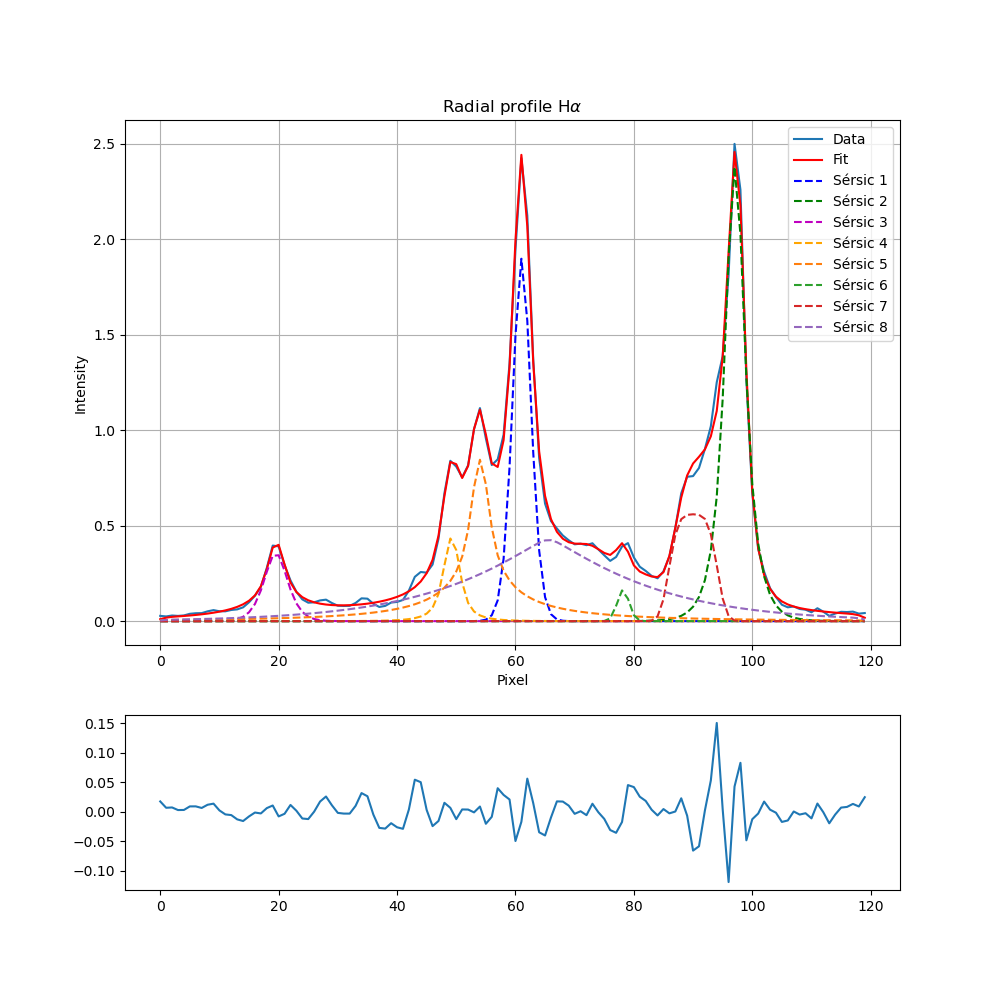

In [29]:
# Plots:
params_curve_8, covariance_8 = curve_fit(lambda x, *params: model_convolved(x, *params), x_axes, radial_profile_HA, 
                                         p0=best_params8, sigma = radial_profile_error_HA)

print("Optimize parameters with curve fit:")

chi_quadr[7], red_chi[7] = save_params(params_curve_8, covariance_8, radial_profile_HA, radial_profile_error_HA, x_axes, 8, 
                                       line_name="Eight", output_prefix="fit")

aic[7] = AIC(x_axes, radial_profile_HA, chi_quadr[7], params_curve_8)
bic[7] = BIC(x_axes, radial_profile_HA, chi_quadr[7], params_curve_8)
print(aic[7], chi_quadr[7], bic[7], len(best_params8))

# Plots:
xgrid = np.linspace(min(x_axes), max(x_axes), 120)
y_fit = model_convolved(xgrid, *params_curve_8)

fig, ax = plt.subplots(2, 1, figsize=(10, 10), height_ratios=[3, 1])

ax[0].plot(x_axes, radial_profile_HA, label='Data')
ax[0].plot(xgrid, y_fit, 'r-', label='Fit')
ax[0].plot(xgrid, sersic_1d_convolved(xgrid, *best_params8[0:4]), 'b--', label='Sérsic 1')
ax[0].plot(xgrid, sersic_1d_convolved(xgrid, *best_params8[4:8]), 'g--', label='Sérsic 2')
ax[0].plot(xgrid, sersic_1d_convolved(xgrid, *best_params8[8:12]), 'm--', label='Sérsic 3')
ax[0].plot(xgrid, sersic_1d_convolved(xgrid, *best_params8[12:16]), color='orange', linestyle='--', label='Sérsic 4')
ax[0].plot(xgrid, sersic_1d_convolved(xgrid, *best_params8[16:20]),  linestyle='--', label='Sérsic 5')
ax[0].plot(xgrid, sersic_1d_convolved(xgrid, *best_params8[20:24]), linestyle='--', label='Sérsic 6')
ax[0].plot(xgrid, sersic_1d_convolved(xgrid, *best_params8[24:28]), linestyle='--', label='Sérsic 7')
ax[0].plot(xgrid, sersic_1d_convolved(xgrid, *best_params8[28:32]), linestyle='--', label='Sérsic 8')

ax[0].set_xlabel("Pixel")
ax[0].set_ylabel("Intensity")
ax[0].set_title(r"Radial profile H$\alpha$")
ax[0].legend()
ax[0].grid(True)

ax[1].plot(x_axes, radial_profile_HA - y_fit)
plt.savefig('AIC_8', bbox_inches='tight')

In [30]:
def model_convolved(x, *params):
    x_hr = np.linspace(min(x), max(x), 4000)
    profile = (
        sersic_1d(x_hr, *params[0:4]) +
        sersic_1d(x_hr, *params[4:8]) +
        sersic_1d(x_hr, *params[8:12]) +
        sersic_1d(x_hr, *params[12:16]) +
        sersic_1d(x_hr, *params[16:20]) +
        sersic_1d(x_hr, *params[20:24]) +
        sersic_1d(x_hr, *params[24:28]) +
        sersic_1d(x_hr, *params[28:32]) +
        sersic_1d(x_hr, *params[32:36])
    )
    kernel = Gaussian1DKernel(stddev=(sigma*len(x_hr))/len(x), x_size=len(x_hr), mode='center')   
    conv_profile = convolve(profile, kernel, mode='same')
    conv_profile_out = np.interp(x, x_hr, conv_profile)
    return conv_profile_out

def chi_squared(params, x, y_obs): #per diff evolution
    y_model = model_convolved(x, *params)
    return np.sum((y_obs - y_model)**2)

# Bounds:
bounds =[
     (0, 10),    # I_e: da 0 a 10 (o un valore ragionevole)
    (0, 50),  # r_e: da 0.1 a 50
    (0.1, 10),  # n: da 0.1 a 10
    (58, 63),   # x_0: posizione da 0 a 100

    (0, 10),
    (0, 50),
    (0.1, 10),
    (95, 100),

    (0, 10),
    (0, 50),
    (0.1, 10),
    (18, 23),

    (0, 10),    # I_e: da 0 a 10 (o un valore ragionevole)
    (0, 50),  # r_e: da 0.1 a 50
    (0.1, 10),  # n: da 0.1 a 10
    (45, 51),    # x_0: posizione da 0 a 100
    
    (0, 10),    # I_e: da 0 a 10 (o un valore ragionevole)
    (0, 50),  # r_e: da 0.1 a 50
    (0.1, 10),  # n: da 0.1 a 10
    (52, 56),   # x_0: posizione da 0 a 100

    (0, 10),    # I_e: da 0 a 10 (o un valore ragionevole)
    (0, 50),  # r_e: da 0.1 a 50
    (0.1, 10),  # n: da 0.1 a 10
    (77, 82),   # x_0: posizione da 0 a 100

    (0, 10),    # I_e: da 0 a 10 (o un valore ragionevole)
    (0, 50),  # r_e: da 0.1 a 50
    (0.1, 10),  # n: da 0.1 a 10
    (85, 90),

    (0, 10),    # I_e: da 0 a 10 (o un valore ragionevole)
    (0, 50),  # r_e: da 0.1 a 50
    (0.1, 10),  # n: da 0.1 a 10
    (0, 100),

    (0, 10),    # I_e: da 0 a 10 (o un valore ragionevole)
    (0, 50),  # r_e: da 0.1 a 50
    (0.1, 10),  # n: da 0.1 a 10
    (0, 100)
]
# objective function for differential_evolution
def objective(params):
    return chi_squared(params, x_axes, radial_profile_HA)

# Global fit:
result = differential_evolution(
    objective,
    bounds,
    strategy='best1bin',
    maxiter=1000,
    popsize=20,
    tol=1e-6,
    disp=True,
    polish=True
)

best_params9 = result.x

print("Optimize parameters with differential_evolution:", best_params9)

print("Chi quadro minimo:", result.fun)

differential_evolution step 1: f(x)= 193313.06112407325
differential_evolution step 2: f(x)= 193313.06112407325
differential_evolution step 3: f(x)= 193313.06112407325
differential_evolution step 4: f(x)= 156264.932564296
differential_evolution step 5: f(x)= 156264.932564296
differential_evolution step 6: f(x)= 112274.93566871934
differential_evolution step 7: f(x)= 112274.93566871934
differential_evolution step 8: f(x)= 112274.93566871934
differential_evolution step 9: f(x)= 112274.93566871934
differential_evolution step 10: f(x)= 95648.79207148927
differential_evolution step 11: f(x)= 29098.30331208443
differential_evolution step 12: f(x)= 29098.30331208443
differential_evolution step 13: f(x)= 29098.30331208443
differential_evolution step 14: f(x)= 29098.30331208443
differential_evolution step 15: f(x)= 29098.30331208443
differential_evolution step 16: f(x)= 24294.86542025707
differential_evolution step 17: f(x)= 24294.86542025707
differential_evolution step 18: f(x)= 18310.06208436

C:\Users\ISAFA\AppData\Local\Temp\ipykernel_12308\111436280.py:9: RuntimeWarning: invalid value encountered in power
  return I_e * np.exp(-b_n * ((r / r_e)**(1 / n) - 1))
C:\Users\ISAFA\AppData\Local\Temp\ipykernel_12308\3765957520.py:15: RuntimeWarning: Use of fft convolution on input with NAN or inf results in NAN or inf output. Consider using method='direct' instead.
  conv_profile = convolve(profile, kernel, mode='same')


Optimize parameters with curve fit:
Sérsic 1: I_e=0.4067, r_e=0.4923, n=1.4257, x_0=61.3910
Sérsic 2: I_e=0.2654, r_e=3.7267, n=1.7113, x_0=97.3663
Sérsic 3: I_e=0.0186, r_e=9.9559, n=2.1988, x_0=19.5894
Sérsic 4: I_e=0.0133, r_e=27.4594, n=2.7100, x_0=49.1296
Sérsic 5: I_e=0.1097, r_e=4.6292, n=1.4663, x_0=53.7673
Sérsic 6: I_e=0.0355, r_e=59.5262, n=0.1751, x_0=82.8595
Sérsic 7: I_e=0.5729, r_e=3.9510, n=0.2489, x_0=91.8091
Sérsic 8: I_e=0.2551, r_e=6.4478, n=0.2022, x_0=74.7008
Sérsic 9: I_e=0.4007, r_e=4.1479, n=1.0497, x_0=60.9048
[1.74322495e+01 1.06553055e+01 4.10258208e+01 5.81006166e-01
 1.46747859e-01 1.19411035e+00 8.05217557e-01 4.30760264e-02
 4.09111314e-02 1.97895520e+01 1.53895296e+00 1.04691108e-01
 5.74061088e-02 7.59710215e+01 3.58387430e+00 6.69183694e-02
 3.41915417e-01 1.44836232e+01 2.09841929e+00 1.46795916e-01
 1.92279439e-02 2.78079222e+02 8.88675585e-01 3.55117455e+02
 4.90545678e-02 8.29126805e-01 6.03571786e-02 1.01899291e+00
 3.15574997e-02 9.58544850e-01 

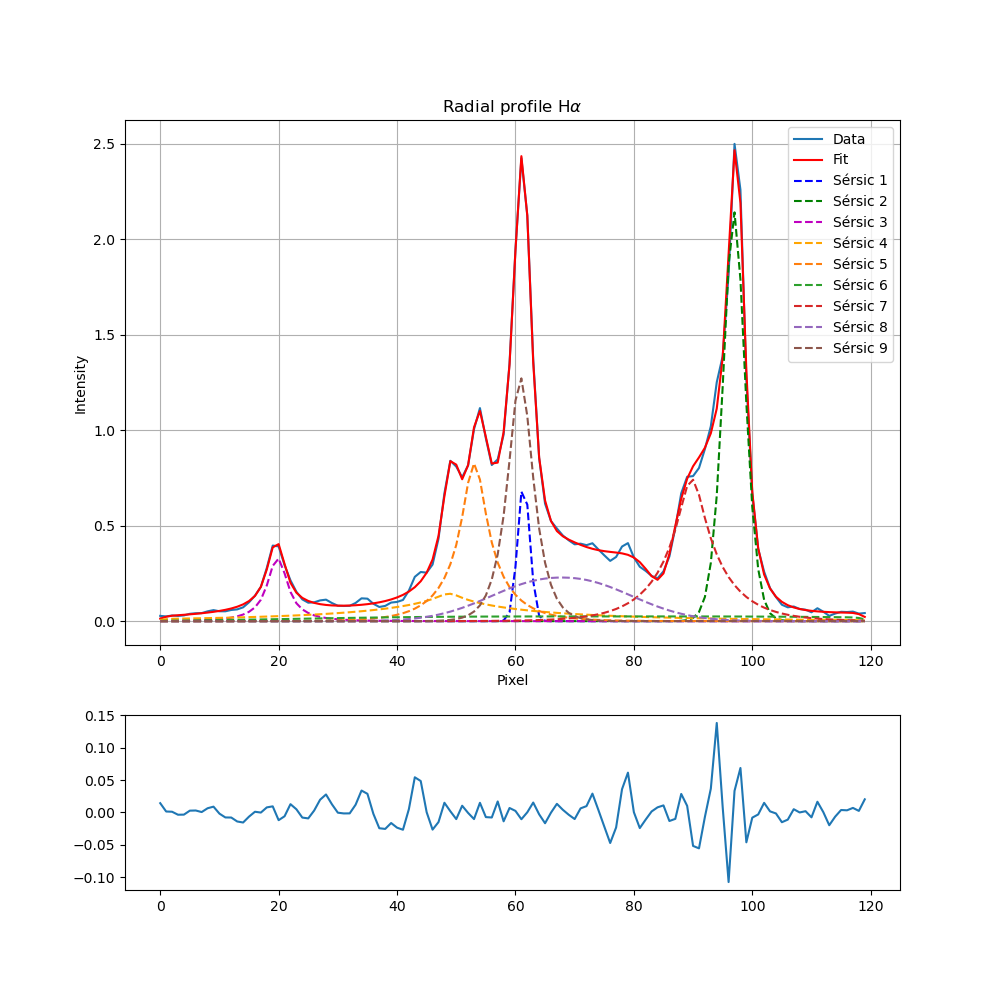

In [31]:

# Plots:
params_curve_9, covariance_9 = curve_fit(lambda x, *params: model_convolved(x, *params), x_axes, radial_profile_HA, 
                                         p0=best_params9, sigma = radial_profile_error_HA)

print("Optimize parameters with curve fit:")

chi_quadr[8], red_chi[8] = save_params(params_curve_9, covariance_9, radial_profile_HA, radial_profile_error_HA, x_axes, 9, 
                                       line_name="Nine", output_prefix="fit")

aic[8] = AIC(x_axes, radial_profile_HA, chi_quadr[8], params_curve_9)
bic[8] = BIC(x_axes, radial_profile_HA, chi_quadr[8], params_curve_9)
print(aic[8], chi_quadr[8], bic[8], len(best_params9))

# Plots:
xgrid = np.linspace(min(x_axes), max(x_axes), 120)
y_fit = model_convolved(xgrid, *params_curve_9)

fig, ax = plt.subplots(2, 1, figsize=(10, 10), height_ratios=[3, 1])

ax[0].plot(x_axes, radial_profile_HA, label='Data')
ax[0].plot(xgrid, y_fit, 'r-', label='Fit')
ax[0].plot(xgrid, sersic_1d_convolved(xgrid, *best_params9[0:4]), 'b--', label='Sérsic 1')
ax[0].plot(xgrid, sersic_1d_convolved(xgrid, *best_params9[4:8]), 'g--', label='Sérsic 2')
ax[0].plot(xgrid, sersic_1d_convolved(xgrid, *best_params9[8:12]), 'm--', label='Sérsic 3')
ax[0].plot(xgrid, sersic_1d_convolved(xgrid, *best_params9[12:16]), color='orange', linestyle='--', label='Sérsic 4')
ax[0].plot(xgrid, sersic_1d_convolved(xgrid, *best_params9[16:20]),  linestyle='--', label='Sérsic 5')
ax[0].plot(xgrid, sersic_1d_convolved(xgrid, *best_params9[20:24]), linestyle='--', label='Sérsic 6')
ax[0].plot(xgrid, sersic_1d_convolved(xgrid, *best_params9[24:28]), linestyle='--', label='Sérsic 7')
ax[0].plot(xgrid, sersic_1d_convolved(xgrid, *best_params9[28:32]), linestyle='--', label='Sérsic 8')
ax[0].plot(xgrid, sersic_1d_convolved(xgrid, *best_params9[32:36]), linestyle='--', label='Sérsic 9')

ax[0].set_xlabel("Pixel")
ax[0].set_ylabel("Intensity")
ax[0].set_title(r"Radial profile H$\alpha$")
ax[0].legend()
ax[0].grid(True)

ax[1].plot(x_axes, radial_profile_HA - y_fit)
plt.savefig('AIC_9', bbox_inches='tight')

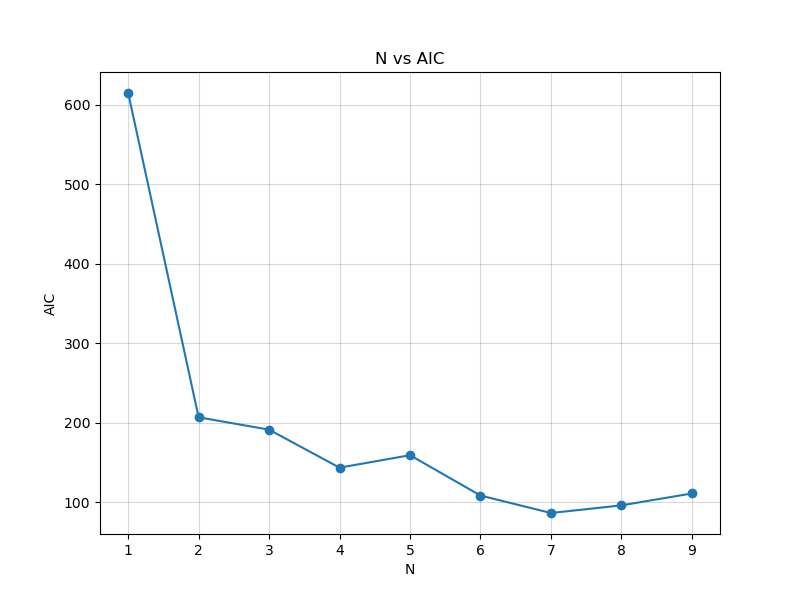

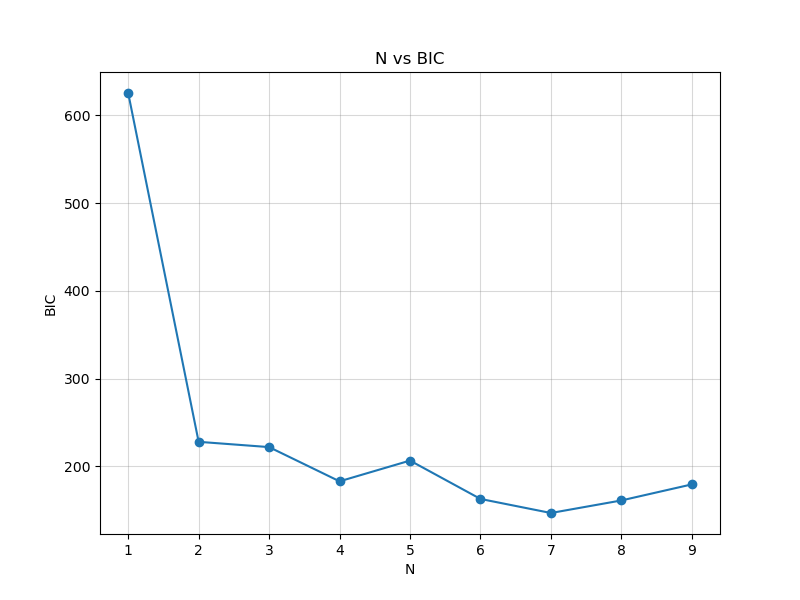

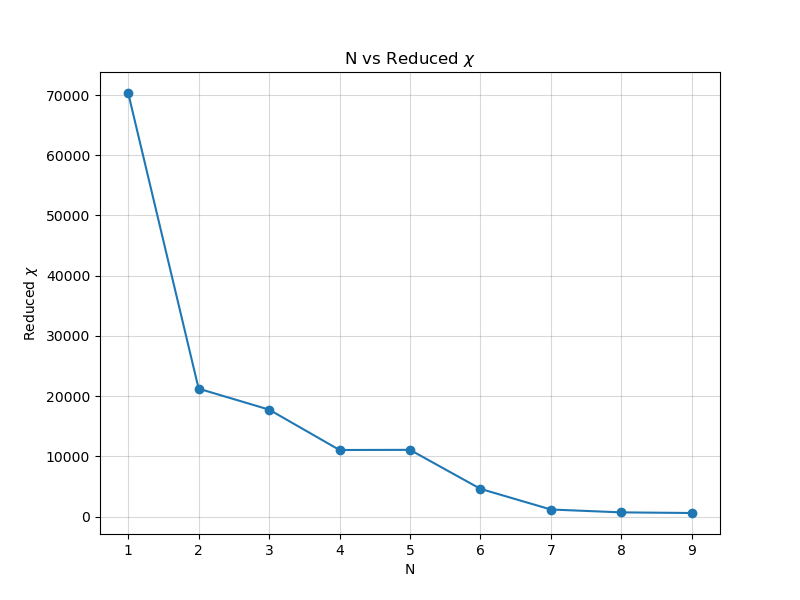

In [32]:
#Plot AIC vs N 
n = [1, 2, 3, 4, 5, 6, 7, 8, 9]

fig1 = plt.figure(figsize=(8,6))
ax1 = fig1.gca()
ax1.grid(alpha=0.3, c = 'grey')
ax1.set_xlabel('N')
ax1.set_ylabel('AIC')
ax1.set_title('N vs AIC')
ax1.plot(n, aic, marker = 'o')
plt.savefig('AIC_vs_N')
np.savetxt('AIC', aic)
np.savetxt('Reduced_chi', red_chi)

fig2 = plt.figure(figsize=(8,6))
ax2 = fig2.gca()
ax2.grid(alpha=0.3, c = 'grey')
ax2.set_xlabel('N')
ax2.set_ylabel('BIC')
ax2.set_title('N vs BIC')
ax2.plot(n, bic, marker = 'o')
plt.savefig('BIC_vs_N')
np.savetxt('BIC', aic)

fig3 = plt.figure(figsize=(8,6))
ax3 = fig3.gca()
ax3.grid(alpha=0.3, c = 'grey')
ax3.set_xlabel('N')
ax3.set_ylabel('Reduced $\chi$')
ax3.set_title('N vs Reduced $\chi$')
ax3.plot(n, red_chi, marker = 'o')
plt.savefig('Reduced_chi_vs_N')

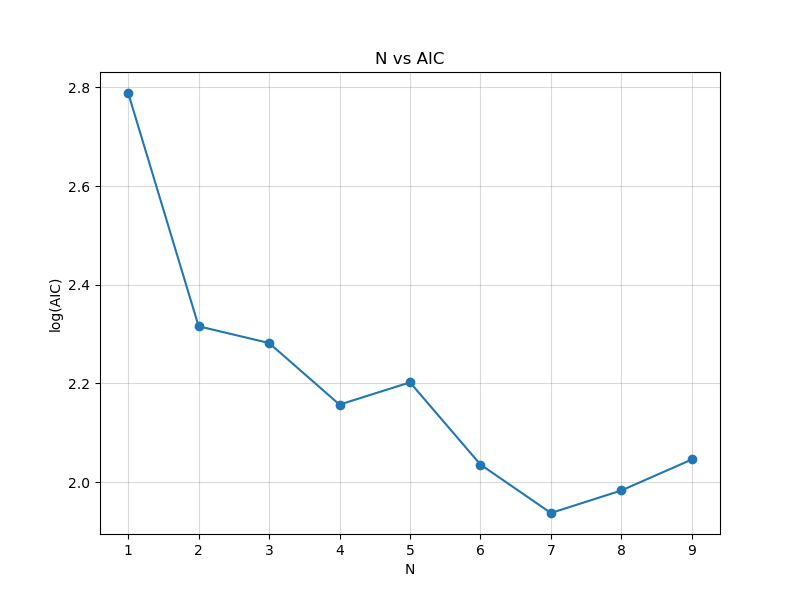

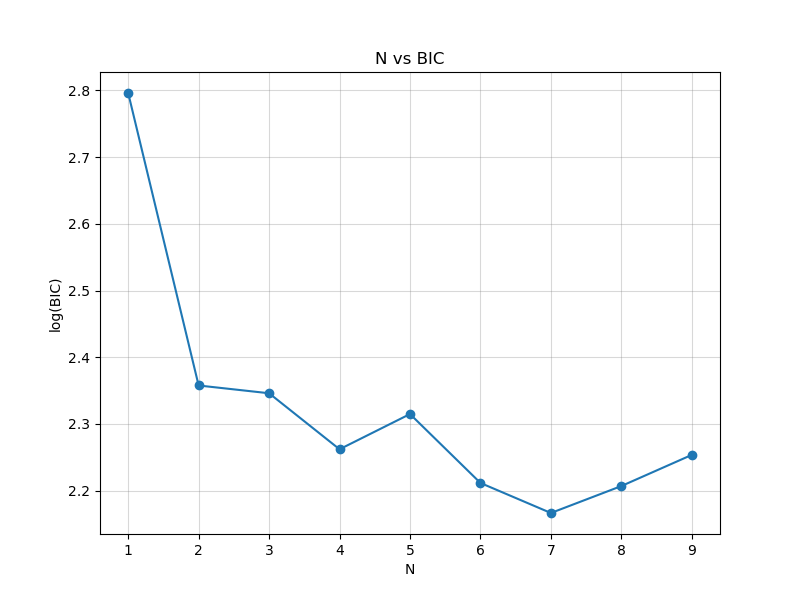

In [33]:
fig1 = plt.figure(figsize=(8,6))
ax1 = fig1.gca()
ax1.grid(alpha=0.3, c = 'grey')
ax1.set_xlabel('N')
ax1.set_ylabel('log(AIC)')
ax1.set_title('N vs AIC')
ax1.plot(n, np.log10(aic), marker = 'o')
plt.savefig('AIC_vs_N_log')

fig2 = plt.figure(figsize=(8,6))
ax2 = fig2.gca()
ax2.grid(alpha=0.3, c = 'grey')
ax2.set_xlabel('N')
ax2.set_ylabel('log(BIC)')
ax2.set_title('N vs BIC')
ax2.plot(n, np.log10(bic), marker = 'o')
plt.savefig('BIC_vs_N_log')